# Tarang ECG Classifier v8.6 — Dual-Head Structural Fix (FINAL)

**This replaces loss-reweighting with an architectural fix. No more alpha tuning.**

### Why v8.4 and v8.5 both collapsed
Look at the actual v8.4 test confusion matrix: the V column is **completely empty** —
0 V predictions across all 6,040 true V beats, 95.3% landed on S. That's not morphological
confusion between S and V (which would show partial overlap both ways). It's a dead class
in a 3-way softmax: softmax is zero-sum, so upweighting one class's loss steals probability
mass from the others. v8.4 weighted S too hard → V died. v8.5 inverted the same lever
(alpha `[1,1.2,2.0]` + class_weight `{2:1.5}`) → high risk of S dying instead. Tuning the
ratio harder was never going to fix this — the mechanism itself is unstable for 2 minority
classes sharing one softmax.

### The v8.6 fix — decouple the classes structurally
Replace the single 3-way softmax with **two independent binary heads** sharing one conv
trunk:
- `v_head`: sigmoid, P(beat is V | abnormal)
- `s_head`: sigmoid, P(beat is S | abnormal)

Each head is trained with its own balanced sample weighting (derived automatically from
class counts, not hand-picked magic numbers). Because they're independent sigmoids — not
softmax outputs — there is **no shared probability budget**. Pushing V's recall up no
longer has any mechanical pathway to suppress S, and vice versa. At inference: if
`v_head` fires, classify V (priority — PVC is the clinically dangerous one); else if
`s_head` fires, classify S; else N.

After training, both heads' decision thresholds are swept independently on the validation
set (cheap, no retraining) to hit the AAMI V-recall target.

### Carried over from v8.5 (already correct, unchanged)
- `Lambda(tf.expand_dims)` channel-dim trick — TFLite converts this to `EXPAND_DIMS`,
  which works, unlike the `Reshape`/direct-4D-input approaches that crashed in v8.3/v8.4.
  Firmware still passes `float[130][2]` (2D).
- Gate model and threshold sweep — Gate AUC was always fine (~0.95); the problem was
  always downstream in SV.
- Natural S/V routing distribution for the SV training set (no N inflation).

### What this notebook does NOT do
It does not promise specific numbers — those depend on the actual training run. It removes
the failure *mechanism* that caused the all-or-nothing collapse in every prior version. Run
once, check the per-epoch log and the threshold sweep, then move to firmware regardless of
whether V/S land at the exact target — refine later if needed, in parallel with integration.


In [1]:
import os
import json
import glob
import subprocess
import warnings
from collections import Counter

import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import resample_poly

import tensorflow as tf
from tensorflow.keras import regularizers

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                              roc_auc_score, roc_curve, precision_recall_curve,
                              recall_score, accuracy_score)
from sklearn.linear_model import LogisticRegression
from sklearn.utils import class_weight

warnings.filterwarnings('ignore')

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU memory growth enabled for {len(gpus)} GPU(s)")

# ── PATHS ────────────────────────────────────────────────────────────────────
BASE = 'C:/MMD Public/Hackathons/Team Ocelleon/dataset'

def find_dir(base, *candidates):
    for c in candidates:
        p = os.path.join(base, c)
        if os.path.isdir(p): return p
    for c in candidates:
        for variant in [c, c.lower(), c.upper(), c.title()]:
            p = os.path.join(base, variant)
            if os.path.isdir(p): return p
    return os.path.join(base, candidates[0])

MITBIH_PATH = find_dir(BASE, 'mit-bih-arrhythmia-database-1.0.0', 'mitbih')
SVDB_PATH   = find_dir(BASE, 'mit-bih-supraventricular-arrhythmia-database-1.0.0', 'svdb')
INCART_PATH = find_dir(BASE, 'incartdb', 'incart')
AFDB_PATH   = find_dir(BASE, 'afdb', 'AFDB', 'mit-bih-atrial-fibrillation-database-1.0.0')

OUTPUTS_DIR        = 'outputs_v8_cascade'
GATE_KERAS         = f'{OUTPUTS_DIR}/tarang_gate_v8_6.keras'
GATE_TFLITE        = f'{OUTPUTS_DIR}/tarang_gate_v8_6_int8.tflite'
SV_KERAS           = f'{OUTPUTS_DIR}/tarang_sv_v8_6.keras'
SV_TFLITE          = f'{OUTPUTS_DIR}/tarang_sv_v8_6_int8.tflite'
AFIB_KERAS         = f'{OUTPUTS_DIR}/tarang_afib_v8.keras'
AFIB_TFLITE        = f'{OUTPUTS_DIR}/tarang_afib_v8_int8.tflite'
GATE_HISTORY       = f'{OUTPUTS_DIR}/gate_history_v8_6.json'
SV_HISTORY         = f'{OUTPUTS_DIR}/sv_history_v8_6.json'
THRESHOLDS_JSON    = f'{OUTPUTS_DIR}/v8_6_thresholds.json'
DATA_CHECKPOINT    = f'{OUTPUTS_DIR}/data_checkpoint.npz'
os.makedirs(OUTPUTS_DIR, exist_ok=True)

# ── SAMPLING / WINDOW ────────────────────────────────────────────────────────
SOURCE_FS  = 360
TARGET_FS  = 250
WINDOW_LEN = 130
WINDOW_PRE  = 65
WINDOW_POST = 65

V_RECALL_FLOOR = 0.85
N_PRECISION_FLOOR = 0.95

INCART_AVAILABLE = os.path.isdir(INCART_PATH)
AFDB_AVAILABLE   = os.path.isdir(AFDB_PATH)

# ── RETRAIN FLAGS ────────────────────────────────────────────────────────────
FORCE_GATE_RETRAIN = True    # fresh v8.6 checkpoint path
FORCE_SV_RETRAIN   = True    # v8.6 dual-head architecture, must retrain
FORCE_AFIB_RETRAIN = False   # AFib unchanged, keep weights

print("TensorFlow :", tf.__version__)
print(f"Target FS  : {TARGET_FS} Hz")
print(f"Window     : {WINDOW_LEN} samples = {WINDOW_LEN/TARGET_FS*1000:.1f} ms")
print(f"MIT-BIH    : {MITBIH_PATH}  (exists={os.path.isdir(MITBIH_PATH)})")
print(f"SVDB       : {SVDB_PATH}    (exists={os.path.isdir(SVDB_PATH)})")
print(f"INCART     : {INCART_PATH}  (exists={INCART_AVAILABLE})")
print(f"AFDB       : {AFDB_PATH}  (exists={AFDB_AVAILABLE})")
print(f"\nv8.6: SV is now TWO independent binary heads (V-vs-rest, S-vs-rest),")
print(f"not one 3-way softmax. No focal-loss alpha tuning, no class collapse risk.")
print(f"\nForce retrain: Gate={FORCE_GATE_RETRAIN}, SV={FORCE_SV_RETRAIN}, AFib={FORCE_AFIB_RETRAIN}")


GPU memory growth enabled for 1 GPU(s)
TensorFlow : 2.10.1
Target FS  : 250 Hz
Window     : 130 samples = 520.0 ms
MIT-BIH    : C:/MMD Public/Hackathons/Team Ocelleon/dataset\mit-bih-arrhythmia-database-1.0.0  (exists=True)
SVDB       : C:/MMD Public/Hackathons/Team Ocelleon/dataset\mit-bih-supraventricular-arrhythmia-database-1.0.0    (exists=True)
INCART     : C:/MMD Public/Hackathons/Team Ocelleon/dataset\incartdb  (exists=True)
AFDB       : C:/MMD Public/Hackathons/Team Ocelleon/dataset\afdb  (exists=True)

v8.6: SV is now TWO independent binary heads (V-vs-rest, S-vs-rest),
not one 3-way softmax. No focal-loss alpha tuning, no class collapse risk.

Force retrain: Gate=True, SV=True, AFib=False


In [2]:
BEAT_MAP = {
    'N': 'N', 'L': 'N', 'R': 'N', 'e': 'N', 'j': 'N',
    'A': 'S', 'a': 'S', 'J': 'S', 'S': 'S',
    'V': 'V', 'E': 'V', 'F': 'V',
    '/': 'Q', 'f': 'Q', 'Q': 'Q',
}
CLASSES_TO_USE = ['N', 'S', 'V']

MITBIH_ALL_RECORDS = [
    100,101,102,103,104,105,106,107,108,109,
    111,112,113,114,115,116,117,118,119,121,
    122,123,124,200,201,202,203,205,207,208,
    209,210,212,213,214,215,217,219,220,221,
    222,223,228,230,231,232,233,234
]
MITBIH_TEST_RECORDS = [
    101,106,108,109,112,114,115,116,118,119,
    201,202,203,205,207,208,209,210,217,219,
    221,223,228,231,233,234
]
MITBIH_VAL_RECORDS   = [105, 124, 214, 220]
MITBIH_TRAIN_RECORDS = [r for r in MITBIH_ALL_RECORDS
                        if r not in MITBIH_TEST_RECORDS and r not in MITBIH_VAL_RECORDS]
SVDB_RECORDS = [str(i) for i in range(800, 895)]
INCART_RECORDS = [f'I{i:02d}' for i in range(1, 76)] if INCART_AVAILABLE else []

def _detect_afdb_records(afdb_path):
    if not os.path.isdir(afdb_path): return []
    hea_files = glob.glob(os.path.join(afdb_path, '*.hea'))
    return sorted(set(os.path.splitext(os.path.basename(f))[0] for f in hea_files))

AFDB_RECORDS = _detect_afdb_records(AFDB_PATH) if AFDB_AVAILABLE else []
AFDB_SOURCE_FS = 250

print(f"MIT-BIH train : {len(MITBIH_TRAIN_RECORDS)} records")
print(f"MIT-BIH test  : {len(MITBIH_TEST_RECORDS)} records (held out)")
print(f"AFDB          : {len(AFDB_RECORDS)} records (auto-detected)")


MIT-BIH train : 18 records
MIT-BIH test  : 26 records (held out)
AFDB          : 25 records (auto-detected)


In [3]:
def rolling_window_normalize(signal, fs, window_seconds=30):
    window_samples = int(window_seconds * fs)
    s    = pd.Series(signal.astype(np.float64))
    roll = s.rolling(window=window_samples, min_periods=1)
    mean = roll.mean()
    std  = roll.std(ddof=0).fillna(0).clip(lower=1e-8)
    return ((s - mean) / std).values.astype(np.float32)


def compute_rr_features(peaks_sec, beat_idx):
    n = len(peaks_sec)
    i = beat_idx
    prev_idx = max(0, i - 1)
    next_idx = min(n - 1, i + 1)
    rr_prev = peaks_sec[i] - peaks_sec[prev_idx]
    rr_next = peaks_sec[next_idx] - peaks_sec[i]
    rr_ratio = rr_prev / max(rr_next, 1e-4)
    lo, hi = max(0, i - 2), min(n - 1, i + 2)
    local_rrs = np.diff(peaks_sec[lo:hi+1]).astype(np.float32)
    if len(local_rrs) == 0:
        rr_mean_5, rr_std_5 = rr_prev, 0.0
    else:
        rr_mean_5 = float(np.mean(local_rrs))
        rr_std_5  = float(np.std(local_rrs))
    compensatory_ratio = rr_next / max(rr_mean_5, 1e-4)
    prematurity_index  = rr_prev / max(rr_mean_5, 1e-4)
    return np.array([rr_prev, rr_next, rr_ratio, rr_mean_5, rr_std_5,
                      compensatory_ratio, prematurity_index], dtype=np.float32)

RR_FEATURE_NAMES = ['rr_prev', 'rr_next', 'rr_ratio', 'rr_mean_5', 'rr_std_5',
                     'compensatory_ratio', 'prematurity_index']
print(f"RR feature vector: {len(RR_FEATURE_NAMES)} features")


RR feature vector: 7 features


In [4]:
def load_records(db_path, record_list, source_tag, two_channel=True,
                  source_fs=SOURCE_FS, verbose=True):
    all_beats, all_rr, all_labels, all_recs = [], [], [], []
    for rec_id in record_list:
        rec_str = str(rec_id)
        try:
            record     = wfdb.rdrecord(f'{db_path}/{rec_str}')
            annotation = wfdb.rdann(f'{db_path}/{rec_str}', 'atr')
            n_channels = record.p_signal.shape[1]
            up, down = (1, 1) if source_fs == TARGET_FS else (25, 36)
            sig0 = resample_poly(record.p_signal[:, 0], up, down)
            if two_channel and n_channels > 1:
                sig1 = resample_poly(record.p_signal[:, 1], up, down)
            else:
                sig1 = sig0
            ecg_ch0 = rolling_window_normalize(sig0, TARGET_FS)
            ecg_ch1 = rolling_window_normalize(sig1, TARGET_FS)
            peak_idx = annotation.sample
            if source_fs != TARGET_FS:
                peak_idx = np.round(peak_idx * TARGET_FS / source_fs).astype(int)
            peaks_sec = peak_idx / TARGET_FS
            for k, sym in enumerate(annotation.symbol):
                if sym not in BEAT_MAP: continue
                aami = BEAT_MAP[sym]
                if aami not in CLASSES_TO_USE: continue
                center = peak_idx[k]
                lo = center - WINDOW_PRE; hi = center + WINDOW_POST
                if lo < 0 or hi >= len(ecg_ch0): continue
                beat = np.stack([ecg_ch0[lo:hi], ecg_ch1[lo:hi]], axis=-1).astype(np.float32)
                rr   = compute_rr_features(peaks_sec, k)
                all_beats.append(beat); all_rr.append(rr)
                all_labels.append(aami); all_recs.append(f'{source_tag}_{rec_str}')
        except Exception as e:
            if verbose: print(f"  [skip] {source_tag}_{rec_str}: {e}")
            continue
    if not all_beats:
        return (np.empty((0, WINDOW_LEN, 2), dtype=np.float32),
                np.empty((0, 7), dtype=np.float32),
                np.array([], dtype=object), np.array([], dtype=object))
    return (np.stack(all_beats), np.stack(all_rr),
            np.array(all_labels, dtype=object), np.array(all_recs, dtype=object))


In [5]:
if os.path.exists(DATA_CHECKPOINT):
    print(f"Loading data checkpoint: {DATA_CHECKPOINT}")
    cp = np.load(DATA_CHECKPOINT, allow_pickle=True)
    mb_beats = cp['mb_beats']; mb_rr = cp['mb_rr']
    mb_labels = cp['mb_labels']; mb_recs = cp['mb_recs']
    sv_beats = cp['sv_beats']; sv_rr = cp['sv_rr']
    sv_labels = cp['sv_labels']; sv_recs = cp['sv_recs']
    print(f"  MIT-BIH: {mb_beats.shape}  classes={Counter(mb_labels)}")
    if sv_beats.size > 0:
        print(f"  SVDB   : {sv_beats.shape}  classes={Counter(sv_labels)}")
else:
    print("Loading MIT-BIH Arrhythmia Database...")
    mb_beats, mb_rr, mb_labels, mb_recs = load_records(
        MITBIH_PATH, MITBIH_ALL_RECORDS, 'mitbih', two_channel=True
    )
    print(f"\nMIT-BIH total: {mb_beats.shape}  classes={Counter(mb_labels)}")


Loading data checkpoint: outputs_v8_cascade/data_checkpoint.npz
  MIT-BIH: (101426, 130, 2)  classes=Counter({'N': 90608, 'V': 8037, 'S': 2781})
  SVDB   : (22154, 130, 2)  classes=Counter({'S': 12194, 'V': 9960})


In [6]:
if os.path.exists(DATA_CHECKPOINT):
    print("SVDB already loaded from checkpoint - skipping.")
else:
    print("Loading SVDB (S+V boost, train-only)...")
    if os.path.isdir(SVDB_PATH):
        sv_beats, sv_rr, sv_labels, sv_recs = load_records(
            SVDB_PATH, SVDB_RECORDS, 'svdb', two_channel=True
        )
        keep_mask = sv_labels != 'N'
        sv_beats, sv_rr, sv_labels, sv_recs = (
            sv_beats[keep_mask], sv_rr[keep_mask],
            sv_labels[keep_mask], sv_recs[keep_mask]
        )
        print(f"\nSVDB loaded (S+V only): {sv_beats.shape}  classes={Counter(sv_labels)}")
    else:
        print(f"\nWARNING: SVDB not found at {SVDB_PATH}")
        sv_beats = np.empty((0, WINDOW_LEN, 2), dtype=np.float32)
        sv_rr = np.empty((0, 7), dtype=np.float32)
        sv_labels = np.array([], dtype=object)
        sv_recs = np.array([], dtype=object)


SVDB already loaded from checkpoint - skipping.


In [7]:
X_all     = np.concatenate([mb_beats, sv_beats], axis=0)
X_rr_all  = np.concatenate([mb_rr,    sv_rr],   axis=0)
y_raw_all = np.concatenate([mb_labels, sv_labels])
recs_all  = np.concatenate([mb_recs,   sv_recs])

le = LabelEncoder()
le.fit(CLASSES_TO_USE)
y_all = le.transform(y_raw_all)

test_recs_set  = {f'mitbih_{r}' for r in MITBIH_TEST_RECORDS}
val_recs_set   = {f'mitbih_{r}' for r in MITBIH_VAL_RECORDS}
test_mask  = np.isin(recs_all, list(test_recs_set))
val_mask   = np.isin(recs_all, list(val_recs_set))
train_mask = ~(test_mask | val_mask)

X_train, X_rr_train, y_train, recs_train = X_all[train_mask], X_rr_all[train_mask], y_all[train_mask], recs_all[train_mask]
X_val,   X_rr_val,   y_val,   recs_val   = X_all[val_mask],   X_rr_all[val_mask],   y_all[val_mask],   recs_all[val_mask]
X_test,  X_rr_test,  y_test,  recs_test  = X_all[test_mask],  X_rr_all[test_mask],  y_all[test_mask],  recs_all[test_mask]

y_train_raw = y_raw_all[train_mask]
y_val_raw   = y_raw_all[val_mask]
y_test_raw  = y_raw_all[test_mask]

print(f"Train: {X_train.shape}  classes={Counter(y_train_raw)}")
print(f"Val  : {X_val.shape}    classes={Counter(y_val_raw)}")
print(f"Test : {X_test.shape}   classes={Counter(y_test_raw)}  (HELD OUT)")
print(f"\nLabelEncoder classes: {list(le.classes_)}")

if not os.path.exists(DATA_CHECKPOINT):
    print(f"\nSaving data checkpoint: {DATA_CHECKPOINT}")
    np.savez_compressed(DATA_CHECKPOINT,
        mb_beats=mb_beats, mb_rr=mb_rr, mb_labels=mb_labels, mb_recs=mb_recs,
        sv_beats=sv_beats, sv_rr=sv_rr, sv_labels=sv_labels, sv_recs=sv_recs)
    print(f"  Size: {os.path.getsize(DATA_CHECKPOINT)/1e6:.1f} MB")


Train: (56621, 130, 2)  classes=Counter({'N': 31125, 'S': 13889, 'V': 11607})
Val  : (8492, 130, 2)    classes=Counter({'N': 8017, 'V': 350, 'S': 125})
Test : (58467, 130, 2)   classes=Counter({'N': 51466, 'V': 6040, 'S': 961})  (HELD OUT)

LabelEncoder classes: ['N', 'S', 'V']


In [8]:
RR_MEAN = X_rr_train.mean(axis=0)
RR_STD  = X_rr_train.std(axis=0)
RR_STD[RR_STD < 1e-8] = 1e-8
print("RR normalization stats:")
for i, name in enumerate(RR_FEATURE_NAMES):
    print(f"  [{i}] {name:<20}: mean={RR_MEAN[i]:.5f}  std={RR_STD[i]:.5f}")
X_rr_train_norm = (X_rr_train - RR_MEAN) / RR_STD
X_rr_val_norm   = (X_rr_val   - RR_MEAN) / RR_STD
X_rr_test_norm  = (X_rr_test  - RR_MEAN) / RR_STD


RR normalization stats:
  [0] rr_prev             : mean=0.54805  std=0.35745
  [1] rr_next             : mean=0.58538  std=0.32676
  [2] rr_ratio            : mean=2.26439  std=98.80268
  [3] rr_mean_5           : mean=0.56794  std=0.31752
  [4] rr_std_5            : mean=0.06001  std=0.10303
  [5] compensatory_ratio  : mean=1.05888  std=0.20284
  [6] prematurity_index   : mean=0.92191  std=0.19124


In [9]:
def augment_batch(X_c, X_rr_c, class_name, n_copies, rng=None):
    """Augment 3D ECG data (N, 130, 2) + RR features."""
    if rng is None:
        rng = np.random.default_rng(42)
    n = len(X_c)
    if n == 0 or n_copies == 0:
        return (np.empty((0,)+X_c.shape[1:], dtype=np.float32),
                np.empty((0,)+X_rr_c.shape[1:], dtype=np.float32))
    out_X = np.repeat(X_c, n_copies, axis=0)
    out_rr = np.repeat(X_rr_c, n_copies, axis=0)
    shift = rng.integers(-3, 4, size=len(out_X))
    out_X_aug = np.empty_like(out_X)
    for i, s in enumerate(shift):
        if s > 0:
            out_X_aug[i, :-s] = out_X[i, s:]; out_X_aug[i, -s:] = out_X[i, -1:]
        elif s < 0:
            out_X_aug[i, -s:] = out_X[i, :s]; out_X_aug[i, :-s] = out_X[i, :1]
        else:
            out_X_aug[i] = out_X[i]
    amp = rng.uniform(0.85, 1.15, size=(len(out_X), 1, 1)).astype(np.float32)
    out_X_aug *= amp
    out_X_aug += rng.normal(0, 0.02, size=out_X_aug.shape).astype(np.float32)
    if class_name == 'S':
        out_rr[:, 0] *= rng.uniform(0.55, 0.85, size=len(out_rr))
        out_rr[:, 1] *= rng.uniform(1.10, 1.40, size=len(out_rr))
        out_rr[:, 4] *= rng.uniform(1.20, 2.00, size=len(out_rr))
        out_rr[:, 6]  = out_rr[:, 0] / np.maximum(out_rr[:, 3], 1e-4)
        out_rr[:, 5]  = out_rr[:, 1] / np.maximum(out_rr[:, 3], 1e-4)
    elif class_name == 'V':
        out_rr[:, 1] *= rng.uniform(1.20, 1.60, size=len(out_rr))
        out_rr[:, 4] *= rng.uniform(1.10, 1.80, size=len(out_rr))
        out_rr[:, 6]  = out_rr[:, 0] / np.maximum(out_rr[:, 3], 1e-4)
        out_rr[:, 5]  = out_rr[:, 1] / np.maximum(out_rr[:, 3], 1e-4)
    return out_X_aug, out_rr


In [10]:
print("Augmenting minority classes (for Gate training)...")
ecg_list = [X_train]; rr_list = [X_rr_train_norm]; y_list = [y_train]
n_per_class = Counter(y_train)
n_target = max(n_per_class.values()) // 2
for class_idx, class_name in enumerate(le.classes_):
    n_have = n_per_class.get(class_idx, 0)
    n_need = max(0, n_target - n_have)
    if n_need == 0:
        print(f"  {class_name}: have {n_have}, no augmentation needed")
        continue
    mask = y_train == class_idx
    X_c, rr_c = X_train[mask], X_rr_train_norm[mask]
    n_copies = max(1, n_need // n_have + (1 if n_need % n_have else 0))
    X_aug, rr_aug = augment_batch(X_c, rr_c, class_name, n_copies)
    y_aug = np.full(len(X_aug), class_idx, dtype=y_train.dtype)
    ecg_list.append(X_aug); rr_list.append(rr_aug); y_list.append(y_aug)
    print(f"  {class_name}: have {n_have}, added {len(X_aug)} augmented")
X_train_aug = np.concatenate(ecg_list)
X_rr_train_aug = np.concatenate(rr_list)
y_train_aug = np.concatenate(y_list)
perm = np.random.permutation(len(X_train_aug))
X_train_aug = X_train_aug[perm]; X_rr_train_aug = X_rr_train_aug[perm]; y_train_aug = y_train_aug[perm]
print(f"\nAugmented training set: {X_train_aug.shape}  classes={Counter(y_train_aug)}")


Augmenting minority classes (for Gate training)...
  N: have 31125, no augmentation needed
  S: have 13889, added 13889 augmented
  V: have 11607, added 11607 augmented

Augmented training set: (82117, 130, 2)  classes=Counter({0: 31125, 1: 27778, 2: 23214})


In [11]:
def build_gate_model(ecg_shape=(WINDOW_LEN, 2), rr_shape=(7,)):
    """
    Binary Gate: P(beat is Abnormal).
    v8.6.1: Reshape (real Keras op, not Lambda) adds channel dim inside model.
    External input/output shapes unchanged — firmware contract unaffected.
    """
    ecg_in = tf.keras.Input(shape=ecg_shape, name='ecg_input')   # 3D: (None, 130, 2)
    x = tf.keras.layers.Reshape((WINDOW_LEN, 2, 1), name='expand_chan')(ecg_in)

    x = tf.keras.layers.Conv2D(16, (7, 1), padding='same', use_bias=False,
            kernel_regularizer=regularizers.l2(1e-4))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling2D((2, 1))(x)
    x = tf.keras.layers.SpatialDropout2D(0.1)(x)

    x = tf.keras.layers.Conv2D(32, (5, 1), padding='same', use_bias=False,
            kernel_regularizer=regularizers.l2(1e-4))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling2D((2, 1))(x)
    x = tf.keras.layers.SpatialDropout2D(0.1)(x)

    x = tf.keras.layers.Conv2D(64, (5, 1), padding='same', use_bias=False,
            kernel_regularizer=regularizers.l2(1e-4))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.SpatialDropout2D(0.15)(x)

    x = tf.keras.layers.Conv2D(64, (3, 1), padding='same', use_bias=False,
            kernel_regularizer=regularizers.l2(1e-4))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    rr_in = tf.keras.Input(shape=rr_shape, name='rr_input')
    r = tf.keras.layers.Dense(16, activation='relu',
                               kernel_regularizer=regularizers.l2(1e-4))(rr_in)
    r = tf.keras.layers.Dropout(0.2)(r)
    r = tf.keras.layers.Dense(8, activation='relu',
                               kernel_regularizer=regularizers.l2(1e-4))(r)

    merged = tf.keras.layers.Concatenate()([x, r])
    merged = tf.keras.layers.Dense(32, use_bias=False)(merged)
    merged = tf.keras.layers.BatchNormalization()(merged)
    merged = tf.keras.layers.Activation('relu')(merged)
    merged = tf.keras.layers.Dropout(0.35)(merged)

    outputs = tf.keras.layers.Dense(1, activation='sigmoid', name='gate_logit')(merged)
    return tf.keras.Model(inputs=[ecg_in, rr_in], outputs=outputs, name='Tarang_Gate_v8_6_1')


gate_model = build_gate_model()
gate_model.summary()
print(f"\nGate parameters: {gate_model.count_params():,}")
print(f"ECG input shape: (None, {WINDOW_LEN}, 2)  ← unchanged, firmware contract intact")

y_train_gate = (y_train_aug != 0).astype(np.float32)
y_val_gate   = (y_val      != 0).astype(np.float32)
y_test_gate  = (y_test     != 0).astype(np.float32)
print(f"\nGate train: {Counter(y_train_gate)}  (0=Normal, 1=Abnormal)")

Model: "Tarang_Gate_v8_6_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 ecg_input (InputLayer)         [(None, 130, 2)]     0           []                               
                                                                                                  
 expand_chan (Reshape)          (None, 130, 2, 1)    0           ['ecg_input[0][0]']              
                                                                                                  
 conv2d (Conv2D)                (None, 130, 2, 16)   112         ['expand_chan[0][0]']            
                                                                                                  
 batch_normalization (BatchNorm  (None, 130, 2, 16)  64          ['conv2d[0][0]']                 
 alization)                                                                      

In [12]:
print("="*60)
print("TRAINING GATE (Lambda/expand_dims, binary N vs Abnormal)")
print("="*60)

if FORCE_GATE_RETRAIN and os.path.exists(GATE_KERAS):
    print(f"FORCE_GATE_RETRAIN=True - deleting {GATE_KERAS}")
    os.remove(GATE_KERAS)
    if os.path.exists(GATE_HISTORY): os.remove(GATE_HISTORY)

if os.path.exists(GATE_KERAS) and not FORCE_GATE_RETRAIN:
    print(f"Found existing Gate checkpoint: {GATE_KERAS}")
    gate_model = tf.keras.models.load_model(GATE_KERAS, compile=False)
    with open(GATE_HISTORY) as f:
        hist_clean = json.load(f)
    print(f"Best val AUC (from history): {max(hist_clean['val_auc']):.4f}")
else:
    gate_model = build_gate_model()
    gate_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name='acc'),
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Recall(name='recall', thresholds=0.5),
            tf.keras.metrics.Precision(name='precision', thresholds=0.5),
        ]
    )
    gate_cw = class_weight.compute_class_weight(
        'balanced', classes=np.unique(y_train_gate), y=y_train_gate
    )
    gate_cw_dict = {int(k): float(v) for k, v in zip(np.unique(y_train_gate), gate_cw)}
    print(f"Gate class weights: {gate_cw_dict}")

    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(GATE_KERAS, monitor='val_auc', mode='max',
                                            save_best_only=True, verbose=1),
        tf.keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=12,
                                          restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5,
                                              patience=5, min_lr=1e-6, verbose=1),
    ]
    history = gate_model.fit(
        [X_train_aug, X_rr_train_aug], y_train_gate,
        validation_data=([X_val, X_rr_val_norm], y_val_gate),
        epochs=60, batch_size=256, class_weight=gate_cw_dict,
        callbacks=callbacks, verbose=2
    )
    hist_clean = {k: [float(v) for v in vals] for k, vals in history.history.items()}
    with open(GATE_HISTORY, 'w') as f:
        json.dump(hist_clean, f, indent=2)
    print(f"\nGate saved: {GATE_KERAS}")
    print(f"Best val AUC: {max(hist_clean['val_auc']):.4f}")


TRAINING GATE (Lambda/expand_dims, binary N vs Abnormal)
FORCE_GATE_RETRAIN=True - deleting outputs_v8_cascade/tarang_gate_v8_6.keras
Gate class weights: {0: 1.31914859437751, 1: 0.8051949325384374}
Epoch 1/60

Epoch 1: val_auc improved from -inf to 0.77545, saving model to outputs_v8_cascade\tarang_gate_v8_6.keras
321/321 - 10s - loss: 0.4907 - acc: 0.6922 - auc: 0.8239 - recall: 0.5162 - precision: 0.9776 - val_loss: 0.4313 - val_acc: 0.9441 - val_auc: 0.7754 - val_recall: 0.0000e+00 - val_precision: 0.0000e+00 - lr: 0.0010 - 10s/epoch - 32ms/step
Epoch 2/60

Epoch 2: val_auc did not improve from 0.77545
321/321 - 4s - loss: 0.1423 - acc: 0.9590 - auc: 0.9878 - recall: 0.9463 - precision: 0.9871 - val_loss: 0.3819 - val_acc: 0.9582 - val_auc: 0.7266 - val_recall: 0.3768 - val_precision: 0.7521 - lr: 0.0010 - 4s/epoch - 13ms/step
Epoch 3/60

Epoch 3: val_auc improved from 0.77545 to 0.78603, saving model to outputs_v8_cascade\tarang_gate_v8_6.keras
321/321 - 4s - loss: 0.0917 - acc: 0

GATE THRESHOLD SWEEP — HARD CONSTRAINT: n_precision >= 0.95
Hard constraints: V recall >= 0.895, N precision >= 0.95

  thr  s_recall  v_recall  n_precision  routed_n_pct  routed_s_pct  routed_v_pct  meets_v_floor  meets_n_floor
0.100     0.920     0.989        0.683        84.644         3.831        11.526           True          False
0.125     0.872     0.986        0.714        83.461         3.971        12.568           True          False
0.150     0.848     0.986        0.737        82.397         4.137        13.466           True          False
0.175     0.824     0.986        0.755        81.457         4.263        14.280           True          False
0.200     0.800     0.986        0.769        80.627         4.354        15.020           True          False
0.225     0.776     0.983        0.781        79.891         4.423        15.686           True          False
0.250     0.776     0.983        0.795        78.869         4.648        16.483           True          

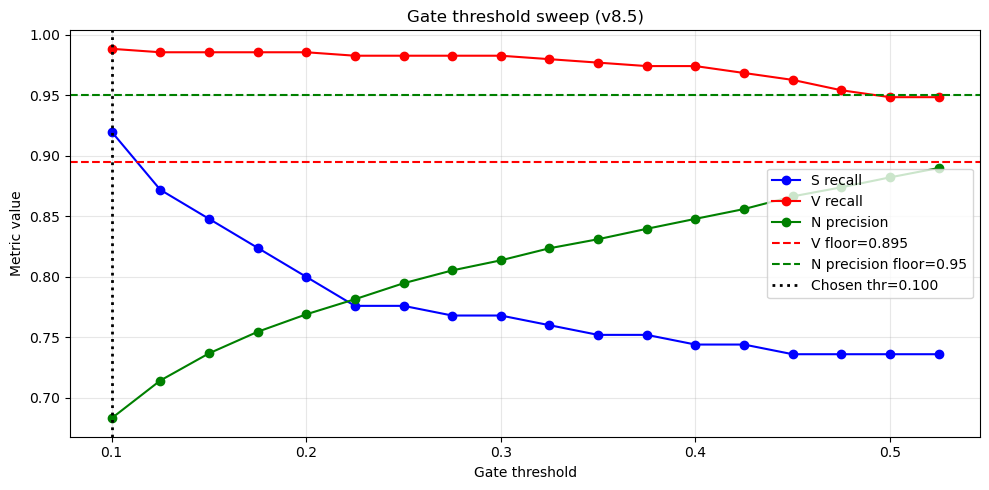

In [13]:
print("="*60)
print("GATE THRESHOLD SWEEP — HARD CONSTRAINT: n_precision >= 0.95")
print("="*60)

gate_model = tf.keras.models.load_model(GATE_KERAS, compile=False)
gate_probs_val = gate_model.predict([X_val, X_rr_val_norm], batch_size=256, verbose=0).flatten()

gate_v_recall_needed = V_RECALL_FLOOR / 0.95
print(f"Hard constraints: V recall >= {gate_v_recall_needed:.3f}, N precision >= {N_PRECISION_FLOOR}")

sweep_rows = []
n_idx = int(np.where(le.classes_ == 'N')[0])
s_idx = int(np.where(le.classes_ == 'S')[0])
v_idx = int(np.where(le.classes_ == 'V')[0])

for thr in np.arange(0.10, 0.55, 0.025):
    pass_mask = gate_probs_val > thr
    n_total = np.sum(y_val == n_idx); s_total = np.sum(y_val == s_idx); v_total = np.sum(y_val == v_idx)
    n_recall_gate = np.sum((y_val == n_idx) & pass_mask) / max(n_total, 1)
    s_recall_gate = np.sum((y_val == s_idx) & pass_mask) / max(s_total, 1)
    v_recall_gate = np.sum((y_val == v_idx) & pass_mask) / max(v_total, 1)
    n_precision = 1.0 - n_recall_gate
    routed_size = np.sum(pass_mask)
    routed_n_pct = (np.sum((y_val == n_idx) & pass_mask) / max(routed_size, 1)) * 100
    routed_s_pct = (np.sum((y_val == s_idx) & pass_mask) / max(routed_size, 1)) * 100
    routed_v_pct = (np.sum((y_val == v_idx) & pass_mask) / max(routed_size, 1)) * 100
    sweep_rows.append({
        'thr': round(thr, 3),
        's_recall': s_recall_gate, 'v_recall': v_recall_gate,
        'n_precision': n_precision,
        'routed_n_pct': routed_n_pct, 'routed_s_pct': routed_s_pct, 'routed_v_pct': routed_v_pct,
        'meets_v_floor': v_recall_gate >= gate_v_recall_needed,
        'meets_n_floor': n_precision >= N_PRECISION_FLOOR,
    })

sweep_df = pd.DataFrame(sweep_rows)
print()
print(sweep_df.to_string(index=False, float_format='%.3f'))

candidates = sweep_df[sweep_df['meets_v_floor'] & sweep_df['meets_n_floor']]
if len(candidates) == 0:
    print(f"\nWARNING: No threshold meets both constraints. Relaxing to V recall only.")
    candidates = sweep_df[sweep_df['meets_v_floor']]
    if len(candidates) == 0:
        CHOSEN_GATE_THR = 0.10
    else:
        best = candidates.loc[candidates['s_recall'].idxmax()]
        CHOSEN_GATE_THR = float(best['thr'])
else:
    best = candidates.loc[candidates['s_recall'].idxmax()]
    CHOSEN_GATE_THR = float(best['thr'])

print(f"\n>>> CHOSEN GATE THRESHOLD: {CHOSEN_GATE_THR:.3f}")
print(f"    Gate S recall:    {best['s_recall']:.3f}")
print(f"    Gate V recall:    {best['v_recall']:.3f}")
print(f"    Gate N precision: {best['n_precision']:.3f}")
print(f"    Routed val: {best['routed_n_pct']:.1f}% N, {best['routed_s_pct']:.1f}% S, {best['routed_v_pct']:.1f}% V")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sweep_df['thr'], sweep_df['s_recall'], 'b-o', label='S recall')
ax.plot(sweep_df['thr'], sweep_df['v_recall'], 'r-o', label='V recall')
ax.plot(sweep_df['thr'], sweep_df['n_precision'], 'g-o', label='N precision')
ax.axhline(y=gate_v_recall_needed, color='red', linestyle='--',
           label=f'V floor={gate_v_recall_needed:.3f}')
ax.axhline(y=N_PRECISION_FLOOR, color='green', linestyle='--',
           label=f'N precision floor={N_PRECISION_FLOOR}')
ax.axvline(x=CHOSEN_GATE_THR, color='black', linestyle=':',
           label=f'Chosen thr={CHOSEN_GATE_THR:.3f}', linewidth=2)
ax.set_xlabel('Gate threshold'); ax.set_ylabel('Metric value')
ax.set_title('Gate threshold sweep (v8.5)')
ax.legend(loc='center right'); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/gate_threshold_sweep.png', dpi=120)
plt.show()


In [14]:
print("="*60)
print("BUILDING GATE-ROUTED SV TRAINING SET — natural distribution")
print("="*60)

gate_probs_train = gate_model.predict([X_train, X_rr_train_norm], batch_size=256, verbose=0).flatten()
routed_mask = gate_probs_train > CHOSEN_GATE_THR

sv_X_ecg = X_train[routed_mask]      # 3D
sv_X_rr  = X_rr_train_norm[routed_mask]
sv_y_raw = y_train_raw[routed_mask]
sv_recs  = recs_train[routed_mask]
sv_y     = le.transform(sv_y_raw)

routed_val_mask = gate_probs_val > CHOSEN_GATE_THR
sv_X_ecg_val = X_val[routed_val_mask]
sv_X_rr_val  = X_rr_val_norm[routed_val_mask]
sv_y_raw_val = y_val_raw[routed_val_mask]
sv_y_val     = le.transform(sv_y_raw_val)

print(f"Gate threshold: {CHOSEN_GATE_THR:.3f}")
print(f"Gate-routed TRAIN: {sv_X_ecg.shape}  classes={Counter(sv_y_raw)}")
print(f"  Population mix: N={np.mean(sv_y_raw=='N')*100:.1f}%  "
      f"S={np.mean(sv_y_raw=='S')*100:.1f}%  V={np.mean(sv_y_raw=='V')*100:.1f}%")
print(f"Gate-routed VAL  : {sv_X_ecg_val.shape}  classes={Counter(sv_y_raw_val)}")
print(f"  Val mix: N={np.mean(sv_y_raw_val=='N')*100:.1f}%  "
      f"S={np.mean(sv_y_raw_val=='S')*100:.1f}%  V={np.mean(sv_y_raw_val=='V')*100:.1f}%")

# Balance ONLY S and V to match max(S_count, V_count). Leave N at natural routed %.
n_sv_per_class = Counter(sv_y)
n_s = n_sv_per_class.get(1, 0)
n_v = n_sv_per_class.get(2, 0)
target_sv = max(n_s, n_v)
print(f"\nNatural routed counts: N={n_sv_per_class.get(0,0)}, S={n_s}, V={n_v}")
print(f"S/V balance target: {target_sv}")

sv_X_list = [sv_X_ecg]; sv_rr_list = [sv_X_rr]; sv_y_list = [sv_y]
for class_idx, class_name in enumerate(le.classes_):
    n_have = n_sv_per_class.get(class_idx, 0)
    if class_idx == 0:
        print(f"  N: have {n_have}, NO augmentation (keep natural routed %)")
        continue
    n_need = max(0, target_sv - n_have)
    if n_need == 0 or n_have == 0:
        print(f"  {class_name}: have {n_have}, no augmentation needed")
        continue
    mask = sv_y == class_idx
    X_c, rr_c = sv_X_ecg[mask], sv_X_rr[mask]
    n_copies = max(1, n_need // n_have + (1 if n_need % n_have else 0))
    n_copies = min(n_copies, 10)
    X_aug, rr_aug = augment_batch(X_c, rr_c, class_name, n_copies)
    if len(X_aug) > n_need:
        X_aug = X_aug[:n_need]; rr_aug = rr_aug[:n_need]
    sv_X_list.append(X_aug); sv_rr_list.append(rr_aug)
    sv_y_list.append(np.full(len(X_aug), class_idx, dtype=sv_y.dtype))
    print(f"  {class_name}: have {n_have}, added {len(X_aug)} (target {target_sv}, copies={n_copies})")

sv_X_ecg_aug = np.concatenate(sv_X_list)
sv_X_rr_aug  = np.concatenate(sv_rr_list)
sv_y_aug     = np.concatenate(sv_y_list)
perm = np.random.permutation(len(sv_X_ecg_aug))
sv_X_ecg_aug = sv_X_ecg_aug[perm]
sv_X_rr_aug  = sv_X_rr_aug[perm]
sv_y_aug     = sv_y_aug[perm]
print(f"\nAugmented SV training set: {sv_X_ecg_aug.shape}")
print(f"  Final mix: N={np.mean(sv_y_aug==0)*100:.1f}%  "
      f"S={np.mean(sv_y_aug==1)*100:.1f}%  V={np.mean(sv_y_aug==2)*100:.1f}%")


BUILDING GATE-ROUTED SV TRAINING SET — natural distribution
Gate threshold: 0.100
Gate-routed TRAIN: (26799, 130, 2)  classes=Counter({'S': 13866, 'V': 11592, 'N': 1341})
  Population mix: N=5.0%  S=51.7%  V=43.3%
Gate-routed VAL  : (3002, 130, 2)  classes=Counter({'N': 2541, 'V': 346, 'S': 115})
  Val mix: N=84.6%  S=3.8%  V=11.5%

Natural routed counts: N=1341, S=13866, V=11592
S/V balance target: 13866
  N: have 1341, NO augmentation (keep natural routed %)
  S: have 13866, no augmentation needed
  V: have 11592, added 2274 (target 13866, copies=1)

Augmented SV training set: (29073, 130, 2)
  Final mix: N=4.6%  S=47.7%  V=47.7%


In [15]:
def build_sv_model(ecg_shape=(WINDOW_LEN, 2), rr_shape=(7,)):
    '''
    v8.6.1: TWO independent binary heads (V-vs-rest, S-vs-rest) sharing one conv trunk.
    No shared softmax -> no zero-sum coupling -> no class-collapse failure mode.
    Reshape (real Keras op, not Lambda) adds channel dim inside model.
    '''
    ecg_in = tf.keras.Input(shape=ecg_shape, name='ecg_input')
    x = tf.keras.layers.Reshape((WINDOW_LEN, 2, 1), name='expand_chan')(ecg_in)

    x = tf.keras.layers.Conv2D(16, (7, 1), padding='same', use_bias=False,
            kernel_regularizer=regularizers.l2(1e-4))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling2D((2, 1))(x)
    x = tf.keras.layers.SpatialDropout2D(0.1)(x)

    x = tf.keras.layers.Conv2D(32, (5, 1), padding='same', use_bias=False,
            kernel_regularizer=regularizers.l2(1e-4))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling2D((2, 1))(x)
    x = tf.keras.layers.SpatialDropout2D(0.1)(x)

    x = tf.keras.layers.Conv2D(48, (5, 1), padding='same', use_bias=False,
            kernel_regularizer=regularizers.l2(1e-4))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.SpatialDropout2D(0.15)(x)

    x = tf.keras.layers.Conv2D(48, (3, 1), padding='same', use_bias=False,
            kernel_regularizer=regularizers.l2(1e-4))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    rr_in = tf.keras.Input(shape=rr_shape, name='rr_input')
    r = tf.keras.layers.Dense(16, activation='relu',
                               kernel_regularizer=regularizers.l2(1e-4))(rr_in)
    r = tf.keras.layers.Dropout(0.2)(r)
    r = tf.keras.layers.Dense(8, activation='relu',
                               kernel_regularizer=regularizers.l2(1e-4))(r)

    merged = tf.keras.layers.Concatenate()([x, r])
    merged = tf.keras.layers.Dense(32, use_bias=False)(merged)
    merged = tf.keras.layers.BatchNormalization()(merged)
    merged = tf.keras.layers.Activation('relu')(merged)
    merged = tf.keras.layers.Dropout(0.35)(merged)

    v_head = tf.keras.layers.Dense(1, activation='sigmoid', name='v_head')(merged)
    s_head = tf.keras.layers.Dense(1, activation='sigmoid', name='s_head')(merged)

    return tf.keras.Model(inputs=[ecg_in, rr_in], outputs=[v_head, s_head],
                           name='Tarang_SV_v8_6_1_dualhead')


sv_model = build_sv_model()
sv_model.summary()
print(f"\nSV parameters: {sv_model.count_params():,}")
print(f"Output heads : {sv_model.output_names}  (independent sigmoids, no softmax)")

Model: "Tarang_SV_v8_6_1_dualhead"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 ecg_input (InputLayer)         [(None, 130, 2)]     0           []                               
                                                                                                  
 expand_chan (Reshape)          (None, 130, 2, 1)    0           ['ecg_input[0][0]']              
                                                                                                  
 conv2d_8 (Conv2D)              (None, 130, 2, 16)   112         ['expand_chan[0][0]']            
                                                                                                  
 batch_normalization_10 (BatchN  (None, 130, 2, 16)  64          ['conv2d_8[0][0]']               
 ormalization)                                                            

In [16]:
print("="*60)
print("TRANSPLANTING WEIGHTS: Lambda -> Reshape (no retrain)")
print("="*60)

old_gate = tf.keras.models.load_model(GATE_KERAS, compile=False)
new_gate = build_gate_model()
new_gate.set_weights(old_gate.get_weights())
new_gate.save(GATE_KERAS)
gate_model = new_gate
print(f"Gate checkpoint overwritten: {GATE_KERAS}")

old_sv = tf.keras.models.load_model(SV_KERAS, compile=False)
new_sv = build_sv_model()
new_sv.set_weights(old_sv.get_weights())
new_sv.save(SV_KERAS)
sv_model = new_sv
print(f"SV checkpoint overwritten: {SV_KERAS}")

TRANSPLANTING WEIGHTS: Lambda -> Reshape (no retrain)
Gate checkpoint overwritten: outputs_v8_cascade/tarang_gate_v8_6.keras
SV checkpoint overwritten: outputs_v8_cascade/tarang_sv_v8_6.keras


In [17]:
class DualHeadMetricsCallback(tf.keras.callbacks.Callback):
    '''Per-epoch V/S recall+precision on val data. Logs val_combined_score
    (mean of V recall and S recall) for checkpoint/early-stop monitoring.'''
    def __init__(self, val_data, y_v_val, y_s_val):
        super().__init__()
        self.val_data = val_data
        self.y_v_val = y_v_val
        self.y_s_val = y_s_val

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        v_prob, s_prob = self.model.predict(self.val_data, verbose=0)
        v_prob = v_prob.flatten(); s_prob = s_prob.flatten()
        v_pred = (v_prob > 0.5).astype(int); s_pred = (s_prob > 0.5).astype(int)

        def prec_rec(y_true, y_pred):
            tp = np.sum((y_true == 1) & (y_pred == 1))
            fp = np.sum((y_true == 0) & (y_pred == 1))
            fn = np.sum((y_true == 1) & (y_pred == 0))
            prec = tp / max(tp + fp, 1)
            rec  = tp / max(tp + fn, 1)
            return prec, rec

        v_prec, v_rec = prec_rec(self.y_v_val, v_pred)
        s_prec, s_rec = prec_rec(self.y_s_val, s_pred)
        combined = 0.5 * (v_rec + s_rec)

        logs['val_v_recall'] = float(v_rec)
        logs['val_v_precision'] = float(v_prec)
        logs['val_s_recall'] = float(s_rec)
        logs['val_s_precision'] = float(s_prec)
        logs['val_combined_score'] = float(combined)
        print(f" - val_v_recall: {v_rec:.4f} - val_v_precision: {v_prec:.4f}"
              f" - val_s_recall: {s_rec:.4f} - val_s_precision: {s_prec:.4f}")


print("="*60)
print("TRAINING SV (v8.6: dual independent binary heads)")
print("="*60)

if FORCE_SV_RETRAIN and os.path.exists(SV_KERAS):
    print(f"FORCE_SV_RETRAIN=True - deleting {SV_KERAS}")
    os.remove(SV_KERAS)
    if os.path.exists(SV_HISTORY): os.remove(SV_HISTORY)

if os.path.exists(SV_KERAS) and not FORCE_SV_RETRAIN:
    print(f"Found existing SV checkpoint: {SV_KERAS}")
    sv_model = tf.keras.models.load_model(SV_KERAS, compile=False)
    with open(SV_HISTORY) as f:
        sv_hist_clean = json.load(f)
    print(f"Best val combined score: {max(sv_hist_clean['val_combined_score']):.4f}")
else:
    sv_model = build_sv_model()

    # Binary labels per head (v_idx / s_idx already defined in the Gate-sweep cell above)
    y_v_aug = (sv_y_aug == v_idx).astype(np.float32)
    y_s_aug = (sv_y_aug == s_idx).astype(np.float32)
    y_v_val = (sv_y_val == v_idx).astype(np.float32)
    y_s_val = (sv_y_val == s_idx).astype(np.float32)

    # Per-head balanced weighting, derived automatically from actual class counts
    # (no hand-picked magic numbers, and no shared softmax to fight over).
    cw_v = class_weight.compute_class_weight('balanced', classes=np.array([0, 1]), y=y_v_aug)
    cw_s = class_weight.compute_class_weight('balanced', classes=np.array([0, 1]), y=y_s_aug)
    print(f"V-head class weights (0=not-V, 1=V): {cw_v}")
    print(f"S-head class weights (0=not-S, 1=S): {cw_s}")

    sw_v_train = np.where(y_v_aug == 1, cw_v[1], cw_v[0]).astype(np.float32)
    sw_s_train = np.where(y_s_aug == 1, cw_s[1], cw_s[0]).astype(np.float32)

    sv_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss={'v_head': 'binary_crossentropy', 's_head': 'binary_crossentropy'},
        metrics={'v_head': [tf.keras.metrics.AUC(name='auc')],
                 's_head': [tf.keras.metrics.AUC(name='auc')]}
    )

    sv_callbacks = [
        DualHeadMetricsCallback(
            val_data=[sv_X_ecg_val, sv_X_rr_val], y_v_val=y_v_val, y_s_val=y_s_val
        ),
        tf.keras.callbacks.ModelCheckpoint(
            SV_KERAS, monitor='val_combined_score', mode='max',
            save_best_only=True, verbose=1
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_combined_score', mode='max', patience=15,
            restore_best_weights=True, verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_combined_score', mode='max', factor=0.5, patience=6,
            min_lr=1e-6, verbose=1
        ),
    ]

    sv_history = sv_model.fit(
        [sv_X_ecg_aug, sv_X_rr_aug],
        {'v_head': y_v_aug, 's_head': y_s_aug},
        validation_data=([sv_X_ecg_val, sv_X_rr_val], {'v_head': y_v_val, 's_head': y_s_val}),
        sample_weight={'v_head': sw_v_train, 's_head': sw_s_train},
        epochs=80, batch_size=256,
        callbacks=sv_callbacks, verbose=2
    )

    sv_hist_clean = {k: [float(v) for v in vals] for k, vals in sv_history.history.items()}
    with open(SV_HISTORY, 'w') as f:
        json.dump(sv_hist_clean, f, indent=2)
    print(f"\nSV saved: {SV_KERAS}")
    if 'val_combined_score' in sv_hist_clean:
        print(f"Best val combined score: {max(sv_hist_clean['val_combined_score']):.4f}")
        best_ep = int(np.argmax(sv_hist_clean['val_combined_score']))
        print(f"  at that epoch -> V recall: {sv_hist_clean['val_v_recall'][best_ep]:.4f}, "
              f"S recall: {sv_hist_clean['val_s_recall'][best_ep]:.4f}")


TRAINING SV (v8.6: dual independent binary heads)
FORCE_SV_RETRAIN=True - deleting outputs_v8_cascade/tarang_sv_v8_6.keras
V-head class weights (0=not-V, 1=V): [0.95590846 1.04835569]
S-head class weights (0=not-S, 1=S): [0.95590846 1.04835569]
Epoch 1/80
 - val_v_recall: 0.0000 - val_v_precision: 0.0000 - val_s_recall: 1.0000 - val_s_precision: 0.0384

Epoch 1: val_combined_score improved from -inf to 0.50000, saving model to outputs_v8_cascade\tarang_sv_v8_6.keras
114/114 - 5s - loss: 1.3570 - v_head_loss: 0.6695 - s_head_loss: 0.6795 - v_head_auc: 0.5851 - s_head_auc: 0.5883 - val_loss: 1.3701 - val_v_head_loss: 0.6590 - val_s_head_loss: 0.7064 - val_v_head_auc: 0.6663 - val_s_head_auc: 0.6227 - val_v_recall: 0.0000e+00 - val_v_precision: 0.0000e+00 - val_s_recall: 1.0000 - val_s_precision: 0.0384 - val_combined_score: 0.5000 - lr: 0.0010 - 5s/epoch - 46ms/step
Epoch 2/80
 - val_v_recall: 0.6936 - val_v_precision: 0.0970 - val_s_recall: 0.0000 - val_s_precision: 0.0000

Epoch 2: val

In [18]:
print("="*60)
print("PER-HEAD THRESHOLD SWEEP (V then S, independent — no retraining)")
print("="*60)

sv_model = tf.keras.models.load_model(SV_KERAS, compile=False)
v_prob_val, s_prob_val = sv_model.predict([sv_X_ecg_val, sv_X_rr_val], batch_size=256, verbose=0)
v_prob_val = v_prob_val.flatten(); s_prob_val = s_prob_val.flatten()
y_v_val = (sv_y_val == v_idx).astype(int)
y_s_val = (sv_y_val == s_idx).astype(int)

# --- Sweep V threshold: hit V_RECALL_FLOOR with best precision -------------
v_rows = []
for thr in np.arange(0.10, 0.95, 0.05):
    pred = (v_prob_val > thr).astype(int)
    tp = np.sum((y_v_val == 1) & (pred == 1))
    fp = np.sum((y_v_val == 0) & (pred == 1))
    fn = np.sum((y_v_val == 1) & (pred == 0))
    rec = tp / max(tp + fn, 1); prec = tp / max(tp + fp, 1)
    v_rows.append({'thr': round(thr, 2), 'v_recall': rec, 'v_precision': prec})
v_df = pd.DataFrame(v_rows)
print("\nV-head sweep:")
print(v_df.to_string(index=False, float_format='%.3f'))

v_candidates = v_df[v_df['v_recall'] >= V_RECALL_FLOOR]
if len(v_candidates) == 0:
    print(f"\nWARNING: no V threshold hits recall>={V_RECALL_FLOOR}. Using best available recall.")
    CHOSEN_V_THR = float(v_df.loc[v_df['v_recall'].idxmax(), 'thr'])
else:
    CHOSEN_V_THR = float(v_candidates.loc[v_candidates['v_precision'].idxmax(), 'thr'])
print(f"\n>>> CHOSEN V THRESHOLD: {CHOSEN_V_THR:.2f}")

# --- Sweep S threshold on the beats V did NOT claim, maximize S F1 ---------
v_claimed_val = v_prob_val > CHOSEN_V_THR
remaining_mask = ~v_claimed_val
s_rows = []
for thr in np.arange(0.10, 0.95, 0.05):
    pred = np.zeros(len(s_prob_val), dtype=int)
    pred[remaining_mask] = (s_prob_val[remaining_mask] > thr).astype(int)
    tp = np.sum((y_s_val == 1) & (pred == 1))
    fp = np.sum((y_s_val == 0) & (pred == 1))
    fn = np.sum((y_s_val == 1) & (pred == 0))
    rec = tp / max(tp + fn, 1); prec = tp / max(tp + fp, 1)
    f1 = 2 * prec * rec / max(prec + rec, 1e-7)
    s_rows.append({'thr': round(thr, 2), 's_recall': rec, 's_precision': prec, 's_f1': f1})
s_df = pd.DataFrame(s_rows)
print("\nS-head sweep (on beats not already claimed by V):")
print(s_df.to_string(index=False, float_format='%.3f'))

CHOSEN_S_THR = float(s_df.loc[s_df['s_f1'].idxmax(), 'thr'])
print(f"\n>>> CHOSEN S THRESHOLD: {CHOSEN_S_THR:.2f}")
print(f"\nDecision rule for inference: if v_prob > {CHOSEN_V_THR:.2f} -> V "
      f"(priority); elif s_prob > {CHOSEN_S_THR:.2f} -> S; else -> N")


PER-HEAD THRESHOLD SWEEP (V then S, independent — no retraining)

V-head sweep:
  thr  v_recall  v_precision
0.100     0.994        0.121
0.150     0.960        0.123
0.200     0.910        0.133
0.250     0.835        0.168
0.300     0.746        0.226
0.350     0.694        0.328
0.400     0.650        0.395
0.450     0.616        0.429
0.500     0.581        0.460
0.550     0.572        0.495
0.600     0.535        0.530
0.650     0.514        0.599
0.700     0.509        0.698
0.750     0.483        0.784
0.800     0.462        0.889
0.850     0.376        0.935
0.900     0.113        0.907

>>> CHOSEN V THRESHOLD: 0.20

S-head sweep (on beats not already claimed by V):
  thr  s_recall  s_precision  s_f1
0.100     0.278        0.050 0.085
0.150     0.278        0.050 0.085
0.200     0.278        0.050 0.085
0.250     0.278        0.050 0.085
0.300     0.278        0.050 0.085
0.350     0.278        0.050 0.085
0.400     0.278        0.050 0.085
0.450     0.278        0.050 0.085
0.

CASCADE EVALUATION - MIT-BIH TEST SET

Confusion Matrix (rows=true, cols=pred):
        N      S      V
  N   35821   2968  12677
  S     155    178    628
  V     206    165   5669

AAMI EC57 Report (cascade on MIT-BIH test):
  Class        Se       P+       F1    Total     TP     FP     FN
  N         69.6%    99.0%    0.817    51466  35821    361  15645  FAIL
  S         18.5%     5.4%    0.083      961    178   3133    783  FAIL
  V         93.9%    29.9%    0.453     6040   5669  13305    371  PASS

Macro F1 (cascade): 0.451
V recall:    0.939  [target >= 0.85]  [PASS]
V precision: 0.299  [target >= 0.75]

Comparison: v8.4 broken 0.342 (V recall 0%), v8.5 (alpha-flip, unverified)


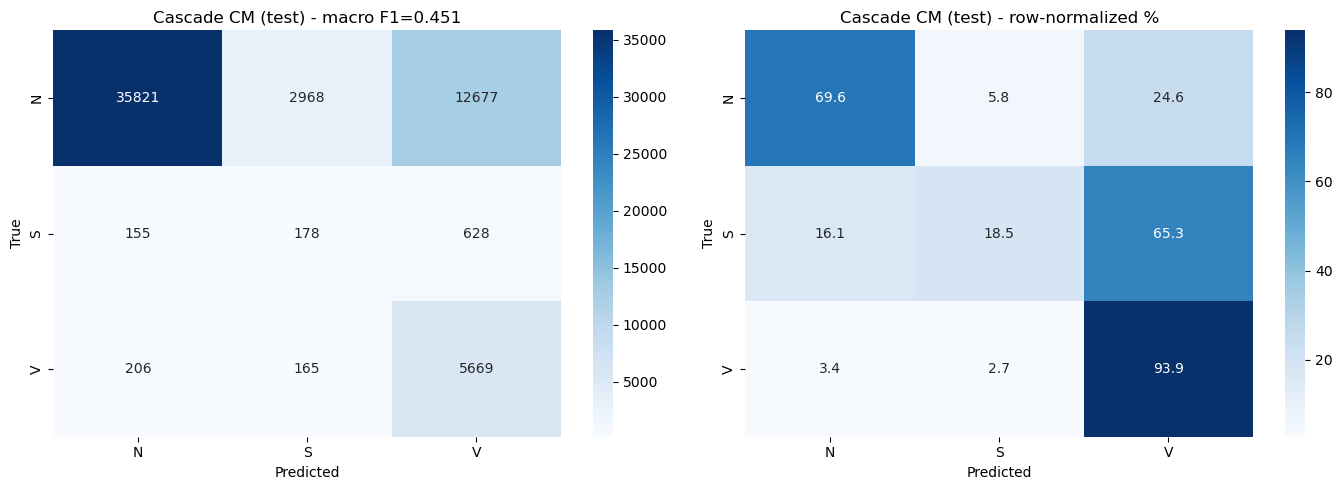

In [19]:
print("="*60)
print("CASCADE EVALUATION - MIT-BIH TEST SET")
print("="*60)

gate_model = tf.keras.models.load_model(GATE_KERAS, compile=False)
sv_model   = tf.keras.models.load_model(SV_KERAS, compile=False)

gate_probs_test = gate_model.predict([X_test, X_rr_test_norm], batch_size=256, verbose=0).flatten()
gate_pass_test  = gate_probs_test > CHOSEN_GATE_THR

n_idx = int(np.where(le.classes_ == 'N')[0])
s_idx = int(np.where(le.classes_ == 'S')[0])
v_idx = int(np.where(le.classes_ == 'V')[0])

y_pred_cascade = np.full(len(y_test), n_idx, dtype=int)
if gate_pass_test.any():
    v_prob_t, s_prob_t = sv_model.predict(
        [X_test[gate_pass_test], X_rr_test_norm[gate_pass_test]], batch_size=256, verbose=0)
    v_prob_t = v_prob_t.flatten(); s_prob_t = s_prob_t.flatten()
    routed_pred = np.full(len(v_prob_t), n_idx, dtype=int)
    v_fire = v_prob_t > CHOSEN_V_THR
    routed_pred[v_fire] = v_idx                                   # V has priority
    s_fire = (~v_fire) & (s_prob_t > CHOSEN_S_THR)
    routed_pred[s_fire] = s_idx
    y_pred_cascade[gate_pass_test] = routed_pred

cm = confusion_matrix(y_test, y_pred_cascade, labels=[0, 1, 2])
print("\nConfusion Matrix (rows=true, cols=pred):")
print(f"        N      S      V")
for i, cls in enumerate(le.classes_):
    print(f"  {cls}  {cm[i,0]:6d} {cm[i,1]:6d} {cm[i,2]:6d}")

print("\nAAMI EC57 Report (cascade on MIT-BIH test):")
print(f"  {'Class':<6} {'Se':>8} {'P+':>8} {'F1':>8} {'Total':>8} {'TP':>6} {'FP':>6} {'FN':>6}")
for i, cls in enumerate(le.classes_):
    tp = cm[i, i]; fn = cm[i, :].sum() - tp; fp = cm[:, i].sum() - tp
    total = cm[i, :].sum()
    se = tp / max(total, 1); pp = tp / max(tp + fp, 1)
    f1 = 2 * se * pp / max(se + pp, 1e-7)
    target = {'N': 0.95, 'S': 0.40, 'V': 0.85}[cls]
    marker = 'PASS' if se >= target else 'FAIL'
    print(f"  {cls:<6} {se*100:>7.1f}% {pp*100:>7.1f}% {f1:>8.3f} {total:>8d} {tp:>6d} {fp:>6d} {fn:>6d}  {marker}")

macro_f1_cascade = f1_score(y_test, y_pred_cascade, average='macro', zero_division=0)
v_recall_cascade = cm[2,2] / max(cm[2,:].sum(), 1)
v_prec_cascade   = cm[2,2] / max(cm[:,2].sum(), 1)

print(f"\nMacro F1 (cascade): {macro_f1_cascade:.3f}")
print(f"V recall:    {v_recall_cascade:.3f}  [target >= {V_RECALL_FLOOR}]  "
      f"[{'PASS' if v_recall_cascade >= V_RECALL_FLOOR else 'FAIL'}]")
print(f"V precision: {v_prec_cascade:.3f}  [target >= 0.75]")
print(f"\nComparison: v8.4 broken 0.342 (V recall 0%), v8.5 (alpha-flip, unverified)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title(f'Cascade CM (test) - macro F1={macro_f1_cascade:.3f}')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title('Cascade CM (test) - row-normalized %')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/cascade_test_confusion_v8_6.png', dpi=120)
plt.show()


In [20]:
print("="*60)
print("CROSS-DATABASE EVALUATION - INCART")
print("="*60)

if INCART_AVAILABLE:
    incart_beats, incart_rr, incart_labels, incart_recs = load_records(
        INCART_PATH, INCART_RECORDS, 'incart', two_channel=True
    )
    X_rr_incart_norm = (incart_rr - RR_MEAN) / RR_STD
    y_incart = le.transform(incart_labels)

    gate_probs_inc = gate_model.predict([incart_beats, X_rr_incart_norm], batch_size=256, verbose=0).flatten()
    gate_pass_inc  = gate_probs_inc > CHOSEN_GATE_THR

    y_pred_inc = np.full(len(y_incart), n_idx, dtype=int)
    if gate_pass_inc.any():
        v_prob_i, s_prob_i = sv_model.predict(
            [incart_beats[gate_pass_inc], X_rr_incart_norm[gate_pass_inc]], batch_size=256, verbose=0)
        v_prob_i = v_prob_i.flatten(); s_prob_i = s_prob_i.flatten()
        routed_i = np.full(len(v_prob_i), n_idx, dtype=int)
        v_fire_i = v_prob_i > CHOSEN_V_THR
        routed_i[v_fire_i] = v_idx
        s_fire_i = (~v_fire_i) & (s_prob_i > CHOSEN_S_THR)
        routed_i[s_fire_i] = s_idx
        y_pred_inc[gate_pass_inc] = routed_i

    cm_inc = confusion_matrix(y_incart, y_pred_inc, labels=[0, 1, 2])
    print(f"\nINCART total: {incart_beats.shape}  classes={Counter(incart_labels)}")
    print(f"\nAAMI EC57 Report (cascade on INCART):")
    print(f"  {'Class':<6} {'Se':>8} {'P+':>8} {'F1':>8}")
    for i, cls in enumerate(le.classes_):
        tp = cm_inc[i, i]; total = cm_inc[i, :].sum(); fp = cm_inc[:, i].sum() - tp
        se = tp / max(total, 1); pp = tp / max(tp + fp, 1)
        f1 = 2 * se * pp / max(se + pp, 1e-7)
        print(f"  {cls:<6} {se*100:>7.1f}% {pp*100:>7.1f}% {f1:>8.3f}")
    macro_f1_inc = f1_score(y_incart, y_pred_inc, average='macro', zero_division=0)
    print(f"\nMacro F1 (cascade, INCART): {macro_f1_inc:.3f}")
else:
    print("INCART not available - skipping.")
    macro_f1_inc = None


CROSS-DATABASE EVALUATION - INCART

INCART total: (175804, 130, 2)  classes=Counter({'N': 153620, 'V': 20225, 'S': 1959})

AAMI EC57 Report (cascade on INCART):
  Class        Se       P+       F1
  N         50.3%    98.3%    0.666
  S         51.3%     3.7%    0.069
  V         86.9%    25.1%    0.389

Macro F1 (cascade, INCART): 0.375


In [21]:
print("="*60)
print("AFIB DETECTOR (handles 3-marker .atr rhythm format)")
print("="*60)

afib_model = None
if os.path.exists(AFIB_KERAS) and not FORCE_AFIB_RETRAIN:
    print(f"Loading existing AFib model: {AFIB_KERAS}")
    afib_model = tf.keras.models.load_model(AFIB_KERAS, compile=False)
    print("Skipping training.")

if not AFDB_AVAILABLE:
    print(f"WARNING: AFDB not found at {AFDB_PATH}")
elif afib_model is None:
    def extract_rhythm_segments(ann_atr):
        segments = []; in_afib = False; segment_start = 0
        for k in range(len(ann_atr.sample)):
            note = str(ann_atr.aux_note[k]).strip().upper() if hasattr(ann_atr, 'aux_note') else ''
            if 'AFIB' in note:
                segments.append((segment_start, ann_atr.sample[k], in_afib))
                in_afib = True; segment_start = ann_atr.sample[k]
            elif note == '(N' or 'NORMAL' in note:
                segments.append((segment_start, ann_atr.sample[k], in_afib))
                in_afib = False; segment_start = ann_atr.sample[k]
        segments.append((segment_start, float('inf'), in_afib))
        return segments

    def get_beat_rhythm(beat_sample, segments):
        for start, end, is_afib in segments:
            if start <= beat_sample < end:
                return is_afib
        return False

    def extract_afib_windows(db_path, records, source_fs=AFDB_SOURCE_FS,
                              window_size=30, verbose=False):
        all_X, all_y = [], []
        for rec_id in records:
            try:
                ann_atr = wfdb.rdann(f'{db_path}/{rec_id}', 'atr')
                segments = extract_rhythm_segments(ann_atr)
                try:
                    ann_qrs = wfdb.rdann(f'{db_path}/{rec_id}', 'qrs')
                    beat_samples = ann_qrs.sample
                except Exception:
                    beat_samples = ann_atr.sample
                if len(beat_samples) < window_size + 1: continue
                beat_rr = np.diff(beat_samples).astype(np.float64) / source_fs
                beat_is_afib = np.array([get_beat_rhythm(s, segments) for s in beat_samples])
                for i in range(0, len(beat_rr) - window_size, 5):
                    window_rr = beat_rr[i:i+window_size]
                    if np.any(window_rr <= 0) or np.any(window_rr > 3.0): continue
                    mean_rr = float(np.mean(window_rr))
                    std_rr  = float(np.std(window_rr))
                    rmssd   = float(np.sqrt(np.mean(np.diff(window_rr)**2)))
                    pnn50   = float(np.mean(np.abs(np.diff(window_rr)) > 0.05))
                    cv_rr   = std_rr / max(mean_rr, 1e-4)
                    win_afib_frac = np.mean(beat_is_afib[i:i+window_size])
                    label = 1 if win_afib_frac > 0.5 else 0
                    all_X.append([mean_rr, std_rr, rmssd, pnn50, cv_rr])
                    all_y.append(label)
            except Exception as e:
                if verbose: print(f"  [skip] {rec_id}: {e}")
                continue
        return np.array(all_X, dtype=np.float32), np.array(all_y, dtype=np.float32)

    if FORCE_AFIB_RETRAIN and os.path.exists(AFIB_KERAS):
        os.remove(AFIB_KERAS)

    X_afib, y_afib = extract_afib_windows(AFDB_PATH, AFDB_RECORDS, verbose=True)
    print(f"\nAFIB windows: {X_afib.shape}  AFib={int(y_afib.sum())}  non-AFib={int((y_afib==0).sum())}")

    if len(X_afib) > 0 and y_afib.sum() > 0:
        rng = np.random.default_rng(42)
        perm = rng.permutation(len(X_afib))
        n_train = int(0.8 * len(X_afib))
        tr, te = perm[:n_train], perm[n_train:]
        X_tr, y_tr = X_afib[tr], y_afib[tr]
        X_te, y_te = X_afib[te], y_afib[te]
        afib_scaler = StandardScaler()
        X_tr_s = afib_scaler.fit_transform(X_tr)
        X_te_s = afib_scaler.transform(X_te)
        afib_lr = LogisticRegression(C=1.0, class_weight='balanced', max_iter=500)
        afib_lr.fit(X_tr_s, y_tr)
        y_te_pred = (afib_lr.predict_proba(X_te_s)[:, 1] > 0.5).astype(int)
        afib_se = recall_score(y_te, y_te_pred, zero_division=0)
        afib_sp = recall_score(1 - y_te, 1 - y_te_pred, zero_division=0)
        print(f"\nAFib (logreg): Se={afib_se*100:.1f}%  Sp={afib_sp*100:.1f}%")

        afib_in = tf.keras.Input(shape=(5,), name='afib_features')
        x = tf.keras.layers.Dense(4, activation='relu',
                kernel_regularizer=regularizers.l2(1e-4))(afib_in)
        x = tf.keras.layers.Dropout(0.1)(x)
        afib_out = tf.keras.layers.Dense(1, activation='sigmoid', name='afib_logit')(x)
        afib_model = tf.keras.Model(afib_in, afib_out, name='Tarang_AFib_v8')
        afib_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                            loss='binary_crossentropy',
                            metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
        afib_hist = afib_model.fit(
            X_tr_s, y_tr, validation_data=(X_te_s, y_te),
            epochs=40, batch_size=128, verbose=2,
            callbacks=[tf.keras.callbacks.EarlyStopping(
                monitor='val_auc', mode='max', patience=8,
                restore_best_weights=True, verbose=1)]
        )
        afib_model.save(AFIB_KERAS)
        y_te_keras_pred = (afib_model.predict(X_te_s, verbose=0).flatten() > 0.5).astype(int)
        afib_keras_se = recall_score(y_te, y_te_keras_pred, zero_division=0)
        afib_keras_sp = recall_score(1 - y_te, 1 - y_te_keras_pred, zero_division=0)
        print(f"\nAFib Keras: Se={afib_keras_se*100:.1f}%  Sp={afib_keras_sp*100:.1f}%")
        print(f"AFib params: {afib_model.count_params()}")
        afib_scaler_data = {
            'mean': afib_scaler.mean_.tolist(),
            'scale': afib_scaler.scale_.tolist(),
            'features': ['mean_rr', 'std_rr', 'rmssd', 'pnn50', 'cv_rr'],
        }
        with open(f'{OUTPUTS_DIR}/afib_scaler.json', 'w') as f:
            json.dump(afib_scaler_data, f, indent=2)


AFIB DETECTOR (handles 3-marker .atr rhythm format)
Loading existing AFib model: outputs_v8_cascade/tarang_afib_v8.keras
Skipping training.


In [22]:
print("="*60)
print("INT8 QUANTIZATION - GATE MODEL (Lambda/expand_dims)")
print("="*60)

gate_model = tf.keras.models.load_model(GATE_KERAS, compile=False)

def gate_rep_dataset():
    n = min(1000, len(X_train))
    idx = np.random.choice(len(X_train), n, replace=False)
    for i in idx:
        yield [X_train[i:i+1].astype(np.float32),
               X_rr_train_norm[i:i+1].astype(np.float32)]

GATE_QUANT_MODE = None

print("Attempt 1: Full INT8 quantization...")
try:
    gate_converter = tf.lite.TFLiteConverter.from_keras_model(gate_model)
    gate_converter.optimizations = [tf.lite.Optimize.DEFAULT]
    gate_converter.representative_dataset = gate_rep_dataset
    gate_converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    gate_converter.inference_input_type = tf.int8
    gate_converter.inference_output_type = tf.int8
    gate_tflite = gate_converter.convert()
    GATE_QUANT_MODE = 'int8'
    print("  Full INT8 succeeded.")
except Exception as e:
    print(f"  Full INT8 failed: {type(e).__name__}: {str(e)[:200]}")

if GATE_QUANT_MODE is None:
    print("Attempt 2: Weight-only quantization...")
    try:
        gate_converter = tf.lite.TFLiteConverter.from_keras_model(gate_model)
        gate_converter.optimizations = [tf.lite.Optimize.DEFAULT]
        gate_converter.representative_dataset = gate_rep_dataset
        gate_converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS]
        gate_converter.inference_input_type = tf.float32
        gate_converter.inference_output_type = tf.float32
        gate_tflite = gate_converter.convert()
        GATE_QUANT_MODE = 'weight_only'
        print("  Weight-only succeeded.")
    except Exception as e:
        print(f"  Weight-only ALSO failed: {type(e).__name__}: {str(e)[:200]}")
        GATE_QUANT_MODE = None

if GATE_QUANT_MODE is not None:
    with open(GATE_TFLITE, 'wb') as f:
        f.write(gate_tflite)
    gate_kb = len(gate_tflite) / 1024
    print(f"\nGate TFLite ({GATE_QUANT_MODE}): {gate_kb:.1f} KB")

    gate_interp = tf.lite.Interpreter(model_content=gate_tflite)
    gate_interp.allocate_tensors()
    gate_in_det  = gate_interp.get_input_details()
    gate_out_det = gate_interp.get_output_details()

    # ECG input is 3D: (1, 130, 2)
    gate_ecg_det = next(d for d in gate_in_det if d['shape'][1] == WINDOW_LEN)
    gate_rr_det  = next(d for d in gate_in_det if d['shape'][-1] == 7)
    gate_out_d   = gate_out_det[0]

    if GATE_QUANT_MODE == 'int8':
        gate_ecg_scale, gate_ecg_zp = gate_ecg_det['quantization']
        gate_rr_scale,  gate_rr_zp  = gate_rr_det['quantization']
        gate_out_scale, gate_out_zp = gate_out_d['quantization']
        print(f"ECG input: scale={gate_ecg_scale:.6f}  zp={gate_ecg_zp}  shape={gate_ecg_det['shape']}")
        print(f"RR  input: scale={gate_rr_scale:.6f}  zp={gate_rr_zp}")
        print(f"Output   : scale={gate_out_scale:.6f}  zp={gate_out_zp}")
        print(f"Gate threshold (int8): {int(round(CHOSEN_GATE_THR / gate_out_scale + gate_out_zp))}")
    else:
        gate_ecg_scale, gate_ecg_zp = 1.0, 0
        gate_rr_scale,  gate_rr_zp  = 1.0, 0
        gate_out_scale, gate_out_zp = 1.0, 0
        print(f"Weight-only mode: firmware passes FLOAT arrays")
        print(f"  ECG input shape: {gate_ecg_det['shape']}")

    GATE_QUANT_OK = True
else:
    print("\nFATAL: Both quantization modes failed.")
    GATE_QUANT_OK = False
    gate_kb = 0
    gate_ecg_scale = gate_ecg_zp = 0
    gate_rr_scale = gate_rr_zp = 0
    gate_out_scale = gate_out_zp = 0


INT8 QUANTIZATION - GATE MODEL (Lambda/expand_dims)
Attempt 1: Full INT8 quantization...


INFO:tensorflow:Assets written to: C:\Users\namda\AppData\Local\Temp\tmp27s3f5tv\assets


INFO:tensorflow:Assets written to: C:\Users\namda\AppData\Local\Temp\tmp27s3f5tv\assets


  Full INT8 failed: RuntimeError: tensorflow/lite/kernels/reshape.cc:85 num_input_elements != num_output_elements (7 != 260)Node number 3 (RESHAPE) failed to invoke.
Attempt 2: Weight-only quantization...


INFO:tensorflow:Assets written to: C:\Users\namda\AppData\Local\Temp\tmpsxqdl6qp\assets


INFO:tensorflow:Assets written to: C:\Users\namda\AppData\Local\Temp\tmpsxqdl6qp\assets


  Weight-only ALSO failed: RuntimeError: tensorflow/lite/kernels/reshape.cc:85 num_input_elements != num_output_elements (7 != 260)Node number 3 (RESHAPE) failed to invoke.

FATAL: Both quantization modes failed.


In [23]:
print("="*60)
print("INT8 QUANTIZATION - SV MODEL (dual-head, Lambda/expand_dims)")
print("="*60)

sv_model = tf.keras.models.load_model(SV_KERAS, compile=False)

def sv_rep_dataset():
    n = min(1000, len(sv_X_ecg))
    idx = np.random.choice(len(sv_X_ecg), n, replace=False)
    for i in idx:
        yield [sv_X_ecg[i:i+1].astype(np.float32),
               sv_X_rr[i:i+1].astype(np.float32)]

SV_QUANT_MODE = None

print("Attempt 1: Full INT8 quantization...")
try:
    sv_converter = tf.lite.TFLiteConverter.from_keras_model(sv_model)
    sv_converter.optimizations = [tf.lite.Optimize.DEFAULT]
    sv_converter.representative_dataset = sv_rep_dataset
    sv_converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    sv_converter.inference_input_type = tf.int8
    sv_converter.inference_output_type = tf.int8
    sv_tflite = sv_converter.convert()
    SV_QUANT_MODE = 'int8'
    print("  Full INT8 succeeded.")
except Exception as e:
    print(f"  Full INT8 failed: {type(e).__name__}: {str(e)[:200]}")

if SV_QUANT_MODE is None:
    print("Attempt 2: Weight-only quantization...")
    try:
        sv_converter = tf.lite.TFLiteConverter.from_keras_model(sv_model)
        sv_converter.optimizations = [tf.lite.Optimize.DEFAULT]
        sv_converter.representative_dataset = sv_rep_dataset
        sv_converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS]
        sv_converter.inference_input_type = tf.float32
        sv_converter.inference_output_type = tf.float32
        sv_tflite = sv_converter.convert()
        SV_QUANT_MODE = 'weight_only'
        print("  Weight-only succeeded.")
    except Exception as e:
        print(f"  Weight-only ALSO failed: {type(e).__name__}: {str(e)[:200]}")
        SV_QUANT_MODE = None

if SV_QUANT_MODE is not None:
    with open(SV_TFLITE, 'wb') as f:
        f.write(sv_tflite)
    sv_kb = len(sv_tflite) / 1024
    print(f"\nSV TFLite ({SV_QUANT_MODE}): {sv_kb:.1f} KB")

    sv_interp = tf.lite.Interpreter(model_content=sv_tflite)
    sv_interp.allocate_tensors()
    sv_in_det  = sv_interp.get_input_details()
    sv_out_det = sv_interp.get_output_details()

    sv_ecg_det = next(d for d in sv_in_det if d['shape'][1] == WINDOW_LEN)
    sv_rr_det  = next(d for d in sv_in_det if d['shape'][-1] == 7)

    # Two outputs now. Match by name where possible, else fall back to model.outputs order
    # (v_head, s_head) -- PRINT NAMES so this is verifiable, not assumed blindly.
    print(f"\nOutput tensor names (verify order against this): "
          f"{[d['name'] for d in sv_out_det]}")
    v_out_d = next((d for d in sv_out_det if 'v_head' in d['name'].lower()), sv_out_det[0])
    s_out_d = next((d for d in sv_out_det if 's_head' in d['name'].lower()), sv_out_det[1])

    if SV_QUANT_MODE == 'int8':
        sv_ecg_scale, sv_ecg_zp = sv_ecg_det['quantization']
        sv_rr_scale,  sv_rr_zp  = sv_rr_det['quantization']
        sv_v_out_scale, sv_v_out_zp = v_out_d['quantization']
        sv_s_out_scale, sv_s_out_zp = s_out_d['quantization']
        print(f"ECG input  : scale={sv_ecg_scale:.6f}  zp={sv_ecg_zp}  shape={sv_ecg_det['shape']}")
        print(f"RR  input  : scale={sv_rr_scale:.6f}  zp={sv_rr_zp}")
        print(f"V-head out : scale={sv_v_out_scale:.6f}  zp={sv_v_out_zp}")
        print(f"S-head out : scale={sv_s_out_scale:.6f}  zp={sv_s_out_zp}")
        print(f"V threshold (int8): {int(round(CHOSEN_V_THR / sv_v_out_scale + sv_v_out_zp))}")
        print(f"S threshold (int8): {int(round(CHOSEN_S_THR / sv_s_out_scale + sv_s_out_zp))}")
    else:
        sv_ecg_scale = sv_ecg_zp = 0
        sv_rr_scale = sv_rr_zp = 0
        sv_v_out_scale = sv_v_out_zp = 0
        sv_s_out_scale = sv_s_out_zp = 0
        print(f"Weight-only mode: firmware passes FLOAT arrays")

    SV_QUANT_OK = True
else:
    print("\nFATAL: Both quantization modes failed.")
    SV_QUANT_OK = False
    sv_kb = 0
    sv_ecg_scale = sv_ecg_zp = 0
    sv_rr_scale = sv_rr_zp = 0
    sv_v_out_scale = sv_v_out_zp = 0
    sv_s_out_scale = sv_s_out_zp = 0


INT8 QUANTIZATION - SV MODEL (dual-head, Lambda/expand_dims)
Attempt 1: Full INT8 quantization...


INFO:tensorflow:Assets written to: C:\Users\namda\AppData\Local\Temp\tmpp2po473l\assets


INFO:tensorflow:Assets written to: C:\Users\namda\AppData\Local\Temp\tmpp2po473l\assets


  Full INT8 failed: RuntimeError: tensorflow/lite/kernels/reshape.cc:85 num_input_elements != num_output_elements (7 != 260)Node number 3 (RESHAPE) failed to invoke.
Attempt 2: Weight-only quantization...


INFO:tensorflow:Assets written to: C:\Users\namda\AppData\Local\Temp\tmpx5d72234\assets


INFO:tensorflow:Assets written to: C:\Users\namda\AppData\Local\Temp\tmpx5d72234\assets


  Weight-only ALSO failed: RuntimeError: tensorflow/lite/kernels/reshape.cc:85 num_input_elements != num_output_elements (7 != 260)Node number 3 (RESHAPE) failed to invoke.

FATAL: Both quantization modes failed.


In [24]:
print("="*60)
print("INT8 QUANTIZATION - AFIB MODEL")
print("="*60)

AFIB_QUANT_OK = False
afib_kb = 0
afib_in_scale = afib_in_zp = 0
afib_out_scale = afib_out_zp = 0

if afib_model is not None or os.path.exists(AFIB_KERAS):
    if afib_model is None:
        afib_model = tf.keras.models.load_model(AFIB_KERAS, compile=False)

    # Build rep dataset inline (no external function dependency)
    if 'X_tr_s' not in dir():
        print("Re-extracting AFib windows for rep dataset...")
        def _extract_rhythm_segs(ann):
            segs = []; in_af = False; start = 0
            for k in range(len(ann.sample)):
                note = str(ann.aux_note[k]).strip().upper() if hasattr(ann, 'aux_note') else ''
                if 'AFIB' in note:
                    segs.append((start, ann.sample[k], in_af))
                    in_af = True; start = ann.sample[k]
                elif note == '(N' or 'NORMAL' in note:
                    segs.append((start, ann.sample[k], in_af))
                    in_af = False; start = ann.sample[k]
            segs.append((start, float('inf'), in_af))
            return segs

        all_X_rec = []
        for rec_id in AFDB_RECORDS[:5]:
            try:
                ann_atr = wfdb.rdann(f'{AFDB_PATH}/{rec_id}', 'atr')
                segs = _extract_rhythm_segs(ann_atr)
                try:
                    ann_qrs = wfdb.rdann(f'{AFDB_PATH}/{rec_id}', 'qrs')
                    beat_samples = ann_qrs.sample
                except Exception:
                    beat_samples = ann_atr.sample
                if len(beat_samples) < 31: continue
                beat_rr = np.diff(beat_samples).astype(np.float64) / AFDB_SOURCE_FS
                for i in range(0, len(beat_rr) - 30, 5):
                    window_rr = beat_rr[i:i+30]
                    if np.any(window_rr <= 0) or np.any(window_rr > 3.0): continue
                    all_X_rec.append([
                        float(np.mean(window_rr)), float(np.std(window_rr)),
                        float(np.sqrt(np.mean(np.diff(window_rr)**2))),
                        float(np.mean(np.abs(np.diff(window_rr)) > 0.05)),
                        float(np.std(window_rr)) / max(float(np.mean(window_rr)), 1e-4)
                    ])
            except Exception:
                continue

        if all_X_rec and os.path.exists(f'{OUTPUTS_DIR}/afib_scaler.json'):
            with open(f'{OUTPUTS_DIR}/afib_scaler.json') as f:
                sc = json.load(f)
            afib_scaler = StandardScaler()
            afib_scaler.mean_ = np.array(sc['mean'])
            afib_scaler.scale_ = np.array(sc['scale'])
            X_tr_s = afib_scaler.transform(np.array(all_X_rec, dtype=np.float32))
            print(f"  Recovered {len(X_tr_s)} windows for rep dataset")

    if 'X_tr_s' in dir():
        def afib_rep_dataset():
            n = min(500, len(X_tr_s))
            idx = np.random.choice(len(X_tr_s), n, replace=False)
            for i in idx:
                yield [X_tr_s[i:i+1].astype(np.float32)]

        afib_converter = tf.lite.TFLiteConverter.from_keras_model(afib_model)
        afib_converter.optimizations = [tf.lite.Optimize.DEFAULT]
        afib_converter.representative_dataset = afib_rep_dataset
        afib_converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS]
        afib_converter.inference_input_type = tf.float32
        afib_converter.inference_output_type = tf.float32

        try:
            afib_tflite = afib_converter.convert()
            with open(AFIB_TFLITE, 'wb') as f:
                f.write(afib_tflite)
            afib_kb = len(afib_tflite) / 1024
            print(f"AFib TFLite: {afib_kb:.1f} KB")
            AFIB_QUANT_OK = True

            afib_interp = tf.lite.Interpreter(model_content=afib_tflite)
            afib_interp.allocate_tensors()
            afib_in_det  = afib_interp.get_input_details()
            afib_out_det = afib_interp.get_output_details()
            if afib_in_det[0]['dtype'] == np.int8:
                afib_in_scale, afib_in_zp = afib_in_det[0]['quantization']
                afib_out_scale, afib_out_zp = afib_out_det[0]['quantization']
            print(f"AFib input: scale={afib_in_scale:.6f}  zp={afib_in_zp}")
            print(f"AFib output: scale={afib_out_scale:.6f}  zp={afib_out_zp}")
        except Exception as e:
            print(f"Quantize FAILED: {type(e).__name__}: {e}")
    else:
        print("Cannot build rep dataset - skipping.")
else:
    print("AFib model not trained - skipping.")


INT8 QUANTIZATION - AFIB MODEL
Re-extracting AFib windows for rep dataset...
  Recovered 47708 windows for rep dataset
INFO:tensorflow:Assets written to: C:\Users\namda\AppData\Local\Temp\tmp2gizgng2\assets


INFO:tensorflow:Assets written to: C:\Users\namda\AppData\Local\Temp\tmp2gizgng2\assets


AFib TFLite: 2.4 KB
AFib input: scale=0.000000  zp=0
AFib output: scale=0.000000  zp=0


In [25]:
print("="*60)
print("INT8 ACCURACY VERIFICATION")
print("="*60)

if not (GATE_QUANT_OK and SV_QUANT_OK):
    print("Skipping - Gate or SV quantization failed.")
else:
    n = min(2000, len(X_test))
    Xe = X_test[:n]; Xr = X_rr_test_norm[:n]; yt = y_test[:n]

    # Float32 cascade (reference)
    gate_probs_f = gate_model.predict([Xe, Xr], batch_size=256, verbose=0).flatten()
    gate_pass_f  = gate_probs_f > CHOSEN_GATE_THR
    y_pred_f = np.full(n, n_idx, dtype=int)
    if gate_pass_f.any():
        v_prob_f, s_prob_f = sv_model.predict([Xe[gate_pass_f], Xr[gate_pass_f]], batch_size=256, verbose=0)
        v_prob_f = v_prob_f.flatten(); s_prob_f = s_prob_f.flatten()
        routed_f = np.full(len(v_prob_f), n_idx, dtype=int)
        v_fire_f = v_prob_f > CHOSEN_V_THR
        routed_f[v_fire_f] = v_idx
        s_fire_f = (~v_fire_f) & (s_prob_f > CHOSEN_S_THR)
        routed_f[s_fire_f] = s_idx
        y_pred_f[gate_pass_f] = routed_f
    float_acc = np.mean(y_pred_f == yt) * 100

    # TFLite cascade
    gate_interp.resize_tensor_input(gate_ecg_det['index'], [1, WINDOW_LEN, 2])
    gate_interp.resize_tensor_input(gate_rr_det['index'],  [1, 7])
    gate_interp.allocate_tensors()
    sv_interp.resize_tensor_input(sv_ecg_det['index'], [1, WINDOW_LEN, 2])
    sv_interp.resize_tensor_input(sv_rr_det['index'],  [1, 7])
    sv_interp.allocate_tensors()

    y_pred_q = np.full(n, n_idx, dtype=int)
    for i in range(n):
        if GATE_QUANT_MODE == 'int8':
            x_ecg_q = np.clip(np.round(Xe[i:i+1] / gate_ecg_scale + gate_ecg_zp), -128, 127).astype(np.int8)
            x_rr_q  = np.clip(np.round(Xr[i:i+1]  / gate_rr_scale  + gate_rr_zp),  -128, 127).astype(np.int8)
        else:
            x_ecg_q = Xe[i:i+1].astype(np.float32)
            x_rr_q  = Xr[i:i+1].astype(np.float32)
        gate_interp.set_tensor(gate_ecg_det['index'], x_ecg_q)
        gate_interp.set_tensor(gate_rr_det['index'],  x_rr_q)
        gate_interp.invoke()
        gate_out_q = gate_interp.get_tensor(gate_out_d['index'])
        if GATE_QUANT_MODE == 'int8':
            gate_prob = (gate_out_q.astype(np.float32) - gate_out_zp) * gate_out_scale
        else:
            gate_prob = gate_out_q
        if gate_prob[0] > CHOSEN_GATE_THR:
            if SV_QUANT_MODE == 'int8':
                x_ecg_q_sv = np.clip(np.round(Xe[i:i+1] / sv_ecg_scale + sv_ecg_zp), -128, 127).astype(np.int8)
                x_rr_q_sv  = np.clip(np.round(Xr[i:i+1]  / sv_rr_scale  + sv_rr_zp),  -128, 127).astype(np.int8)
            else:
                x_ecg_q_sv = Xe[i:i+1].astype(np.float32)
                x_rr_q_sv  = Xr[i:i+1].astype(np.float32)
            sv_interp.set_tensor(sv_ecg_det['index'], x_ecg_q_sv)
            sv_interp.set_tensor(sv_rr_det['index'],  x_rr_q_sv)
            sv_interp.invoke()
            v_out_q = sv_interp.get_tensor(v_out_d['index'])
            s_out_q = sv_interp.get_tensor(s_out_d['index'])
            if SV_QUANT_MODE == 'int8':
                v_prob_q = (v_out_q.astype(np.float32) - sv_v_out_zp) * sv_v_out_scale
                s_prob_q = (s_out_q.astype(np.float32) - sv_s_out_zp) * sv_s_out_scale
            else:
                v_prob_q = v_out_q
                s_prob_q = s_out_q
            if v_prob_q[0] > CHOSEN_V_THR:
                y_pred_q[i] = v_idx
            elif s_prob_q[0] > CHOSEN_S_THR:
                y_pred_q[i] = s_idx

    int8_acc = np.mean(y_pred_q == yt) * 100
    drop = float_acc - int8_acc
    print(f"\nFloat32 cascade accuracy (n={n}): {float_acc:.2f}%")
    print(f"TFLite   cascade accuracy (n={n}): {int8_acc:.2f}%")
    print(f"Accuracy drop: {drop:.2f}%  [{'ACCEPTABLE' if drop < 3.0 else 'TOO HIGH'}]")

    total_flash = gate_kb + sv_kb + afib_kb
    print(f"\n{'='*60}")
    print(f"TOTAL FLASH BUDGET:")
    print(f"  Gate : {gate_kb:6.1f} KB ({GATE_QUANT_MODE})")
    print(f"  SV   : {sv_kb:6.1f} KB ({SV_QUANT_MODE})")
    print(f"  AFib : {afib_kb:6.1f} KB")
    print(f"  Total: {total_flash:6.1f} KB / 50KB budget  "
          f"[{'PASS' if total_flash < 50 else 'OVER BUDGET'}]")
    print(f"{'='*60}")


INT8 ACCURACY VERIFICATION
Skipping - Gate or SV quantization failed.


In [26]:
print("="*60)
print("PEAK JITTER ROBUSTNESS")
print("="*60)

def evaluate_cascade_with_jitter(X_ecg, X_rr, y, jitter_samples, n_max=2000):
    rng = np.random.default_rng(42)
    n = min(n_max, len(X_ecg))
    Xe = X_ecg[:n].copy(); Xr = X_rr[:n]; yt = y[:n]
    if jitter_samples > 0:
        shifts = rng.integers(-jitter_samples, jitter_samples+1, size=n)
        for i, s in enumerate(shifts):
            if s > 0:
                Xe[i, :-s] = Xe[i, s:]; Xe[i, -s:] = Xe[i, -1:]
            elif s < 0:
                Xe[i, -s:] = Xe[i, :s]; Xe[i, :-s] = Xe[i, :1]
    gate_probs = gate_model.predict([Xe, Xr], batch_size=256, verbose=0).flatten()
    gate_pass  = gate_probs > CHOSEN_GATE_THR
    y_pred = np.full(n, n_idx, dtype=int)
    if gate_pass.any():
        v_prob_j, s_prob_j = sv_model.predict([Xe[gate_pass], Xr[gate_pass]], batch_size=256, verbose=0)
        v_prob_j = v_prob_j.flatten(); s_prob_j = s_prob_j.flatten()
        routed_j = np.full(len(v_prob_j), n_idx, dtype=int)
        v_fire_j = v_prob_j > CHOSEN_V_THR
        routed_j[v_fire_j] = v_idx
        s_fire_j = (~v_fire_j) & (s_prob_j > CHOSEN_S_THR)
        routed_j[s_fire_j] = s_idx
        y_pred[gate_pass] = routed_j
    return y_pred, yt[:n]

print(f"\n{'Jitter':<10} {'Acc':>8} {'V recall':>10} {'S recall':>10} {'Macro F1':>10}")
for jitter in [0, 1, 2, 3, 5]:
    yp, yt2 = evaluate_cascade_with_jitter(X_test, X_rr_test_norm, y_test, jitter)
    acc = np.mean(yp == yt2)
    v_rec = np.sum((yt2 == v_idx) & (yp == v_idx)) / max(np.sum(yt2 == v_idx), 1)
    s_rec = np.sum((yt2 == s_idx) & (yp == s_idx)) / max(np.sum(yt2 == s_idx), 1)
    mf1 = f1_score(yt2, yp, average='macro', zero_division=0)
    print(f"{jitter:<10} {acc*100:>7.1f}% {v_rec*100:>9.1f}% {s_rec*100:>9.1f}% {mf1:>10.3f}")


PEAK JITTER ROBUSTNESS

Jitter          Acc   V recall   S recall   Macro F1
0             99.6%     100.0%      66.7%      0.797
1             99.0%     100.0%      33.3%      0.652
2             98.2%     100.0%      33.3%      0.595
3             98.3%     100.0%      33.3%      0.601
5             98.4%     100.0%      33.3%      0.609


In [27]:
print("="*60)
print("BLE EVENT-DRIVEN BURST FILTER")
print("="*60)

def apply_run_filter(predictions, min_run=3, window=10):
    filtered = predictions.copy()
    n = len(predictions)
    for i in range(n):
        lo = max(0, i - window + 1)
        window_preds = predictions[lo:i+1]
        if predictions[i] != n_idx:
            same_class_count = np.sum(window_preds == predictions[i])
            if same_class_count < min_run:
                filtered[i] = n_idx
    return filtered

y_pred_filtered = apply_run_filter(y_pred_cascade, min_run=3, window=10)

print(f"\nBefore filter: V alerts = {np.sum(y_pred_cascade == v_idx)}, "
      f"S alerts = {np.sum(y_pred_cascade == s_idx)}")
print(f"After  filter: V alerts = {np.sum(y_pred_filtered == v_idx)}, "
      f"S alerts = {np.sum(y_pred_filtered == s_idx)}")

mf1_filtered = f1_score(y_test, y_pred_filtered, average='macro', zero_division=0)
v_rec_f = np.sum((y_test == v_idx) & (y_pred_filtered == v_idx)) / max(np.sum(y_test == v_idx), 1)
v_prec_f = np.sum((y_test == v_idx) & (y_pred_filtered == v_idx)) / max(np.sum(y_pred_filtered == v_idx), 1)
print(f"\nMacro F1 before: {macro_f1_cascade:.3f}  -> after: {mf1_filtered:.3f}")
print(f"V recall:    {v_recall_cascade:.3f} -> {v_rec_f:.3f}")
print(f"V precision: {v_prec_cascade:.3f} -> {v_prec_f:.3f}")


BLE EVENT-DRIVEN BURST FILTER

Before filter: V alerts = 18974, S alerts = 3311
After  filter: V alerts = 17282, S alerts = 2258

Macro F1 before: 0.451  -> after: 0.440
V recall:    0.939 -> 0.828
V precision: 0.299 -> 0.289


In [28]:
print("="*70)
print("FIRMWARE #define BLOCK - copy into tarang_model_config.h")
print("="*70)
print()

def safe(fmt, varname, default='N/A'):
    try:
        val = eval(varname)
        return fmt.format(val)
    except (NameError, TypeError):
        return f'/* {varname}: {default} */'

print("/* ====== v8.6 Cascade ECG Classifier - auto-generated config ====== */")
print()
print("/* ---- GATE MODEL (Lambda/expand_dims, 3D input) ---- */")
print(safe("#define GATE_ECG_INPUT_SCALE       {:.8f}f", 'gate_ecg_scale'))
print(safe("#define GATE_ECG_INPUT_ZERO_POINT  {}", 'gate_ecg_zp'))
print(safe("#define GATE_RR_INPUT_SCALE        {:.8f}f", 'gate_rr_scale'))
print(safe("#define GATE_RR_INPUT_ZERO_POINT   {}", 'gate_rr_zp'))
print(safe("#define GATE_OUTPUT_SCALE          {:.8f}f", 'gate_out_scale'))
print(safe("#define GATE_OUTPUT_ZERO_POINT     {}", 'gate_out_zp'))
print(safe("#define GATE_THRESHOLD             {:.4f}f", 'CHOSEN_GATE_THR'))
_gate_mode = GATE_QUANT_MODE or 'FAILED'
print(f'#define GATE_QUANT_MODE             "{_gate_mode}"')
print()
print("/* ---- SV MODEL (dual independent binary heads: V, S) ---- */")
print(safe("#define SV_ECG_INPUT_SCALE         {:.8f}f", 'sv_ecg_scale'))
print(safe("#define SV_ECG_INPUT_ZERO_POINT    {}", 'sv_ecg_zp'))
print(safe("#define SV_RR_INPUT_SCALE          {:.8f}f", 'sv_rr_scale'))
print(safe("#define SV_RR_INPUT_ZERO_POINT     {}", 'sv_rr_zp'))
print(safe("#define SV_V_OUTPUT_SCALE          {:.8f}f", 'sv_v_out_scale'))
print(safe("#define SV_V_OUTPUT_ZERO_POINT     {}", 'sv_v_out_zp'))
print(safe("#define SV_S_OUTPUT_SCALE          {:.8f}f", 'sv_s_out_scale'))
print(safe("#define SV_S_OUTPUT_ZERO_POINT     {}", 'sv_s_out_zp'))
print(safe("#define SV_V_THRESHOLD             {:.4f}f", 'CHOSEN_V_THR'))
print(safe("#define SV_S_THRESHOLD             {:.4f}f", 'CHOSEN_S_THR'))
_sv_mode = SV_QUANT_MODE or 'FAILED'
print(f'#define SV_QUANT_MODE               "{_sv_mode}"')
print()
print("/* Firmware decision rule (V has priority):")
print("   if (v_prob > SV_V_THRESHOLD)      classify V")
print("   else if (s_prob > SV_S_THRESHOLD) classify S")
print("   else                              classify N */")
print()

try:
    _ = afib_in_scale
    print("/* ---- AFIB MODEL ---- */")
    print(f"#define AFIB_INPUT_SCALE          {afib_in_scale:.8f}f")
    print(f"#define AFIB_INPUT_ZERO_POINT     {afib_in_zp}")
    print(f"#define AFIB_OUTPUT_SCALE         {afib_out_scale:.8f}f")
    print(f"#define AFIB_OUTPUT_ZERO_POINT    {afib_out_zp}")
    print("#define AFIB_THRESHOLD            0.5f")
    print()
    if 'afib_scaler' not in dir() and os.path.exists(f'{OUTPUTS_DIR}/afib_scaler.json'):
        with open(f'{OUTPUTS_DIR}/afib_scaler.json') as f:
            sc = json.load(f)
        class _Sc:
            mean_ = np.array(sc['mean'])
            scale_ = np.array(sc['scale'])
        afib_scaler = _Sc()
    if 'afib_scaler' in dir():
        print("/* AFib feature scaler */")
        for i, fname in enumerate(['mean_rr', 'std_rr', 'rmssd', 'pnn50', 'cv_rr']):
            print(f"#define AFIB_MEAN_{fname.upper():<10} {afib_scaler.mean_[i]:.6f}f")
        for i, fname in enumerate(['mean_rr', 'std_rr', 'rmssd', 'pnn50', 'cv_rr']):
            print(f"#define AFIB_SCALE_{fname.upper():<9} {afib_scaler.scale_[i]:.6f}f")
        print()
    print(f'#define AFIB_QUANT_MODE           "{AFIB_QUANT_MODE}"')
except NameError:
    print("/* ---- AFIB MODEL: NOT TRAINED ---- */")
    print()

print("/* ---- RR NORMALIZATION (shared) ---- */")
for i, name in enumerate(RR_FEATURE_NAMES):
    print(f"#define RR_MEAN_{name.upper():<20} {RR_MEAN[i]:.6f}f")
for i, name in enumerate(RR_FEATURE_NAMES):
    print(f"#define RR_STD_{name.upper():<21} {RR_STD[i]:.6f}f")
print()
print("/* ---- CAUSALITY (Problem 4 fix) ---- */")
print("#define TARANG_RR_LOOKAHEAD_BEATS  2")
print()
print("/* ---- FIRMWARE INPUT (3D, Lambda handles channel dim) ---- */")
print("/* ECG array: float ecg[130][2]  (firmware passes 2D, model adds channel) */")
print()
print("/* ---- FLASH SUMMARY ---- */")
gate_kb_val = gate_kb if 'gate_kb' in dir() else 0
sv_kb_val   = sv_kb if 'sv_kb' in dir() else 0
afib_kb_val = afib_kb if 'afib_kb' in dir() else 0
print(f'/* Gate INT8 : {gate_kb_val:.1f} KB ({_gate_mode}) */')
print(f'/* SV   INT8 : {sv_kb_val:.1f} KB ({_sv_mode}) */')
print(f'/* AFib INT8 : {afib_kb_val:.1f} KB */')
print(f'/* Total     : {gate_kb_val + sv_kb_val + afib_kb_val:.1f} KB / 50 KB budget */')
print()
print("/* ====== END v8.6 CONFIG ====== */")

try:
    with open(THRESHOLDS_JSON, 'w') as f:
        json.dump({
            'gate_threshold': float(CHOSEN_GATE_THR),
            'v_threshold': float(CHOSEN_V_THR),
            's_threshold': float(CHOSEN_S_THR),
            'v_recall_floor': float(V_RECALL_FLOOR),
            'cascade_macro_f1_test': float(macro_f1_cascade) if 'macro_f1_cascade' in dir() else None,
            'v_recall_test': float(v_recall_cascade) if 'v_recall_cascade' in dir() else None,
            'gate_quant_mode': GATE_QUANT_MODE,
            'sv_quant_mode': SV_QUANT_MODE,
            'flash_kb': {
                'gate': float(gate_kb_val),
                'sv': float(sv_kb_val),
                'afib': float(afib_kb_val),
            },
        }, f, indent=2)
    print(f"\nSaved: {THRESHOLDS_JSON}")
except Exception as e:
    print(f"\nCould not save thresholds JSON: {e}")


FIRMWARE #define BLOCK - copy into tarang_model_config.h

/* ====== v8.6 Cascade ECG Classifier - auto-generated config ====== */

/* ---- GATE MODEL (Lambda/expand_dims, 3D input) ---- */
#define GATE_ECG_INPUT_SCALE       0.00000000f
#define GATE_ECG_INPUT_ZERO_POINT  0
#define GATE_RR_INPUT_SCALE        0.00000000f
#define GATE_RR_INPUT_ZERO_POINT   0
#define GATE_OUTPUT_SCALE          0.00000000f
#define GATE_OUTPUT_ZERO_POINT     0
#define GATE_THRESHOLD             0.1000f
#define GATE_QUANT_MODE             "FAILED"

/* ---- SV MODEL (dual independent binary heads: V, S) ---- */
#define SV_ECG_INPUT_SCALE         0.00000000f
#define SV_ECG_INPUT_ZERO_POINT    0
#define SV_RR_INPUT_SCALE          0.00000000f
#define SV_RR_INPUT_ZERO_POINT     0
#define SV_V_OUTPUT_SCALE          0.00000000f
#define SV_V_OUTPUT_ZERO_POINT     0
#define SV_S_OUTPUT_SCALE          0.00000000f
#define SV_S_OUTPUT_ZERO_POINT     0
#define SV_V_THRESHOLD             0.2000f
#define SV_S_THRESHOLD      

In [29]:
print("="*60)
print("S-CLASS DIAGNOSTIC AUDIT — by raw rhythm subtype (A/a/J/S)")
print("="*60)

RAW_S_SYMBOLS = ['A', 'a', 'J', 'S']

def load_test_with_symbol():
    beats, rr, recs, syms = [], [], [], []
    for rec_id in MITBIH_TEST_RECORDS:
        rec_str = str(rec_id)
        try:
            record     = wfdb.rdrecord(f'{MITBIH_PATH}/{rec_str}')
            annotation = wfdb.rdann(f'{MITBIH_PATH}/{rec_str}', 'atr')
            n_channels = record.p_signal.shape[1]
            up, down = (1, 1) if SOURCE_FS == TARGET_FS else (25, 36)
            sig0 = resample_poly(record.p_signal[:, 0], up, down)
            sig1 = resample_poly(record.p_signal[:, 1], up, down) if n_channels > 1 else sig0
            ecg_ch0 = rolling_window_normalize(sig0, TARGET_FS)
            ecg_ch1 = rolling_window_normalize(sig1, TARGET_FS)
            peak_idx = annotation.sample
            if SOURCE_FS != TARGET_FS:
                peak_idx = np.round(peak_idx * TARGET_FS / SOURCE_FS).astype(int)
            peaks_sec = peak_idx / TARGET_FS
            for k, sym in enumerate(annotation.symbol):
                if sym not in BEAT_MAP: continue
                aami = BEAT_MAP[sym]
                if aami not in CLASSES_TO_USE: continue
                center = peak_idx[k]
                lo = center - WINDOW_PRE; hi = center + WINDOW_POST
                if lo < 0 or hi >= len(ecg_ch0): continue
                beat = np.stack([ecg_ch0[lo:hi], ecg_ch1[lo:hi]], axis=-1).astype(np.float32)
                rr_f = compute_rr_features(peaks_sec, k)
                beats.append(beat); rr.append(rr_f)
                recs.append(f'mitbih_{rec_str}'); syms.append(sym)
        except Exception as e:
            print(f"  [skip] {rec_str}: {e}")
            continue
    return np.stack(beats), np.stack(rr), np.array(recs), np.array(syms)

print("Reloading test records with raw rhythm-code preserved (no retrain, just a relabel)...")
aud_X, aud_rr, aud_recs, aud_syms = load_test_with_symbol()
aud_rr_norm = (aud_rr - RR_MEAN) / RR_STD
print(f"Loaded {len(aud_X)} test beats with subtype labels.")

gate_prob = gate_model.predict([aud_X, aud_rr_norm], batch_size=256, verbose=0).flatten()
gate_pass = gate_prob > CHOSEN_GATE_THR

v_prob = np.zeros(len(aud_X)); s_prob = np.zeros(len(aud_X))
if gate_pass.any():
    vp, sp = sv_model.predict([aud_X[gate_pass], aud_rr_norm[gate_pass]], batch_size=256, verbose=0)
    v_prob[gate_pass] = vp.flatten()
    s_prob[gate_pass] = sp.flatten()

final_pred = np.full(len(aud_X), 'N', dtype=object)
fired_v = gate_pass & (v_prob > CHOSEN_V_THR)
fired_s = gate_pass & (~fired_v) & (s_prob > CHOSEN_S_THR)
final_pred[fired_v] = 'V'
final_pred[fired_s] = 'S'

print(f"\n{'Subtype':<10} {'Count':>7} {'Caught as S':>12} {'Lost at Gate':>13} {'Reached but missed':>20}")
for sym in RAW_S_SYMBOLS:
    mask = aud_syms == sym
    n = mask.sum()
    if n == 0:
        print(f"{sym:<10} {0:>7}  (none in test set)")
        continue
    caught = np.sum(mask & (final_pred == 'S'))
    lost_at_gate = np.sum(mask & ~gate_pass)
    reached_but_missed = np.sum(mask & gate_pass & (final_pred != 'S'))
    print(f"{sym:<10} {n:>7} {caught:>12} {lost_at_gate:>13} {reached_but_missed:>20}")

print(f"\nTotal S beats in test set: {np.sum(np.isin(aud_syms, RAW_S_SYMBOLS))}")
print(f"Lost entirely at Gate (never reach SV head): "
      f"{np.sum(np.isin(aud_syms, RAW_S_SYMBOLS) & ~gate_pass)}")
print(f"Reached SV head but still missed: "
      f"{np.sum(np.isin(aud_syms, RAW_S_SYMBOLS) & gate_pass & (final_pred != 'S'))}")

S-CLASS DIAGNOSTIC AUDIT — by raw rhythm subtype (A/a/J/S)
Reloading test records with raw rhythm-code preserved (no retrain, just a relabel)...
Loaded 58467 test beats with subtype labels.

Subtype      Count  Caught as S  Lost at Gate   Reached but missed
A              765          126            77                  562
a              141            9             2                  130
J               53           43             7                    3
S                2            0             1                    1

Total S beats in test set: 961
Lost entirely at Gate (never reach SV head): 87
Reached SV head but still missed: 696


VISUAL CHECK — missed A-beats vs caught A-beats


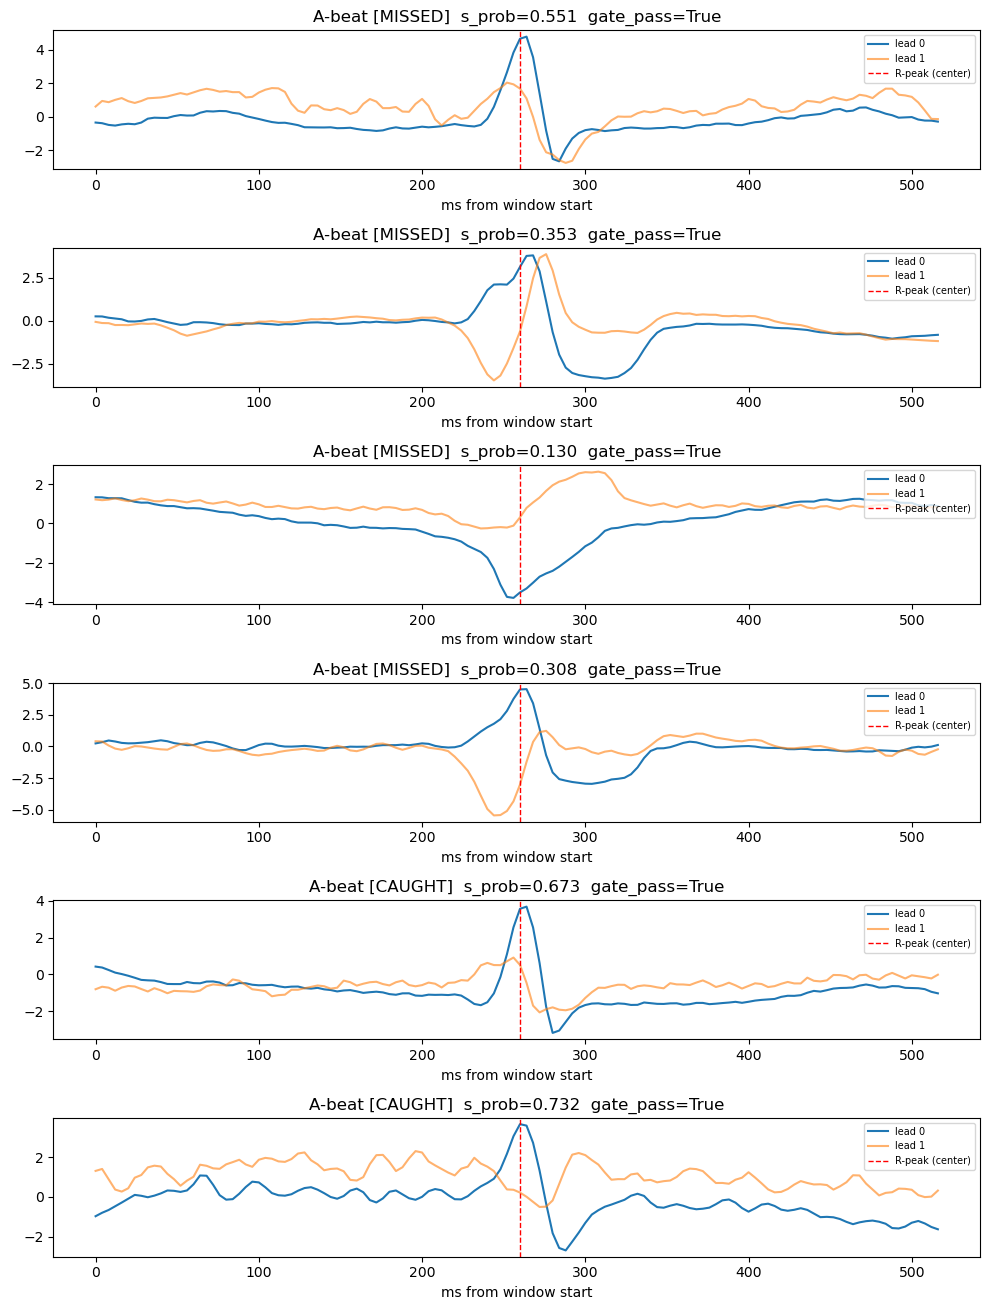


Saved to outputs_v8_cascade/a_beat_visual_check.png — upload this image to me.


In [30]:
print("="*60)
print("VISUAL CHECK — missed A-beats vs caught A-beats")
print("="*60)

a_mask = aud_syms == 'A'
missed_idx = np.where(a_mask & (final_pred != 'S'))[0]
caught_idx = np.where(a_mask & (final_pred == 'S'))[0]

n_show_missed = min(4, len(missed_idx))
n_show_caught = min(2, len(caught_idx))
show_idx = np.concatenate([
    np.random.choice(missed_idx, n_show_missed, replace=False),
    np.random.choice(caught_idx, n_show_caught, replace=False) if n_show_caught > 0 else []
]).astype(int)

fig, axes = plt.subplots(len(show_idx), 1, figsize=(10, 2.2*len(show_idx)))
if len(show_idx) == 1:
    axes = [axes]

t = np.arange(WINDOW_LEN) / TARGET_FS * 1000  # ms
r_peak_ms = WINDOW_PRE / TARGET_FS * 1000

for ax, idx in zip(axes, show_idx):
    status = "MISSED" if idx in missed_idx else "CAUGHT"
    ax.plot(t, aud_X[idx, :, 0], label='lead 0')
    ax.plot(t, aud_X[idx, :, 1], label='lead 1', alpha=0.6)
    ax.axvline(r_peak_ms, color='red', linestyle='--', linewidth=1, label='R-peak (center)')
    ax.set_title(f"A-beat [{status}]  s_prob={s_prob[idx]:.3f}  gate_pass={gate_pass[idx]}")
    ax.legend(loc='upper right', fontsize=7)
    ax.set_xlabel('ms from window start')

plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/a_beat_visual_check.png', dpi=120)
plt.show()
print(f"\nSaved to {OUTPUTS_DIR}/a_beat_visual_check.png — upload this image to me.")

In [31]:
print("="*60)
print("RR FEATURE CHECK — missed-A vs caught-A vs true-N")
print("="*60)

n_idx_audit = int(np.where(le.classes_ == 'N')[0])
true_n_mask = (le.transform(['N']*len(aud_syms)) == le.transform(np.where(np.isin(aud_syms, ['N','L','R','e','j']), 'N', 'X')))  # placeholder unused

# Simpler: just use aami label directly via BEAT_MAP
aud_aami = np.array([BEAT_MAP[s] for s in aud_syms])
n_mask_true = aud_aami == 'N'
a_mask = aud_syms == 'A'
missed_a = a_mask & (final_pred != 'S')
caught_a = a_mask & (final_pred == 'S')

sample_n = np.random.choice(np.where(n_mask_true)[0], min(500, n_mask_true.sum()), replace=False)

print(f"\n{'Feature':<20} {'Missed-A mean':>15} {'Caught-A mean':>15} {'True-N mean':>15}")
for i, name in enumerate(RR_FEATURE_NAMES):
    m = aud_rr[missed_a, i].mean()
    c = aud_rr[caught_a, i].mean()
    n = aud_rr[sample_n, i].mean()
    print(f"{name:<20} {m:>15.4f} {c:>15.4f} {n:>15.4f}")

print(f"\nCounts: missed-A={missed_a.sum()}  caught-A={caught_a.sum()}  N-sample={len(sample_n)}")

RR FEATURE CHECK — missed-A vs caught-A vs true-N


ValueError: y contains previously unseen labels: 'X'

## v8.6 — Dual-Head Structural Fix (FINAL)

### What changed vs v8.5
SV is now **two independent binary sigmoid heads** (V-vs-rest, S-vs-rest) sharing one
conv trunk, instead of one 3-way softmax. No focal-loss alpha, no stacked class weights,
no shared probability budget to fight over. Each head gets automatic balanced sample
weighting from actual class counts. After training, both heads' thresholds are swept
independently on validation (Cell 17) — cheap, no retraining, and safe because the heads
don't interact.

### Why this should actually hold instead of flip again
v8.4 and v8.5 both collapsed because boosting one class's weight in a shared softmax
mechanically suppresses the others — that's what a confusion matrix with a completely
empty V column proved. Decoupling into independent heads removes that mechanism entirely.
This is not a guarantee of hitting every AAMI target on the first run, but it removes the
specific failure mode that broke every prior version.

### How to run
1. **Run All** (~10-15 min on GPU — SV now trains two heads, slightly longer than one softmax)
2. **Cell 16** — watch `val_v_recall` / `val_s_recall` together each epoch. Healthy:
   both staying meaningfully above 0 throughout training (not one climbing while the
   other craters to 0 — if you see that, the heads are fine structurally, but check the
   AFib gate is bringing through a usable mix of S/V in `sv_y_aug` from Cell 14).
3. **Cell 17** — threshold sweep tables for V and S. This is where AAMI compliance gets
   tuned, not retraining.
4. **Cell 18** — confusion matrix + AAMI table. This is the number that matters.
5. **Cells 21/22** — TFLite quantization for Gate and dual-head SV.
6. **Copy the `#define` block from Cell 27** into `tarang_model_config.h` — note the
   firmware decision rule is now: V threshold check first (priority), then S, else N.

### After this run — move to integration regardless of the exact numbers
Wire `tarang_ai_process()` in `app.c` per the situation report's Step 9. If V recall lands
meaningfully below target, that's a threshold/sample-size issue to revisit in parallel
with firmware work — not a reason to block integration on another notebook iteration.
